In [16]:
#importing necessary libraries and loading the dataset

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sys

sys.path.append("../scripts")

import importlib
import feature_engineering

importlib.reload(feature_engineering)

dir(feature_engineering)
from plotting_style import style_chart
from feature_engineering import (
    create_smoking_score,
    create_hba1c_group,
    create_alcohol_frequency_features
)
df = pd.read_csv("/Users/hughesy/Documents/FinalProject/data/processed/analytical_dataset.csv")
df = create_smoking_score(df)
df = create_hba1c_group(df)
df = create_alcohol_frequency_features(df)

## Demographics

In [31]:
df["age"].describe()

count    8153.000000
mean       52.144364
std        18.553060
min        18.000000
25%        36.000000
50%        55.000000
75%        68.000000
max        80.000000
Name: age, dtype: float64

In [33]:
# Create category mapping dictionaries for better readability in plots
#  Demographics

gender_labels = {
    1: "Male",
    2: "Female"
}

ethnicity_labels = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    6: "Non-Hispanic Asian",
    7: "Other / Multi-Racial"
}

# Alcohol

alc_consum_labels = {
    1: "Yes",
    2: "No"
}

alcohol_map = {
    0: "Former / None Last Year",

    1: "Daily / Near Daily",
    2: "Daily / Near Daily",

    3: "Weekly",
    4: "Weekly",
    5: "Weekly",

    6: "Monthly",
    7: "Monthly",

    8: "Few Times / Year",
    9: "Few Times / Year",
    10: "Few Times / Year"
}


# Smoking

smoked_100_cigs_labels = {
    1: "Yes",
    2: "No"
}

smoker_now_labels = {
    1: "Every Day",
    2: "Some Days",
    3: "Not At All"
}


# Blood Pressure

high_bp_labels = {
    1: "Yes",
    2: "No"
}

bp_medication_labels = {
    1: "Yes",
    2: "No"
}


# Cholesterol

high_cholesterol_labels = {
    1: "Yes",
    2: "No"
}

cholesterol_medication_labels = {
    1: "Yes",
    2: "No"
}


# Diabetes

diabetes_labels = {
    1: "Yes",
    2: "No",
    3: "Borderline"
}

pre_diabetes_labels = {
    1: "Yes",
    2: "No"
}

insulin_labels = {
    1: "Yes",
    2: "No"
}

diabetes_medication_labels = {
    1: "Yes",
    2: "No"
}

In [34]:
# distribution of age and gender
pd.crosstab(df["age"], df["gender"].map(gender_labels), normalize="index") * 100

gender,Female,Male
age,,
18.0,44.021739,55.978261
19.0,58.750000,41.250000
20.0,43.661972,56.338028
21.0,48.809524,51.190476
22.0,54.117647,45.882353
...,...,...
76.0,49.038462,50.961538
77.0,58.333333,41.666667
78.0,61.643836,38.356164


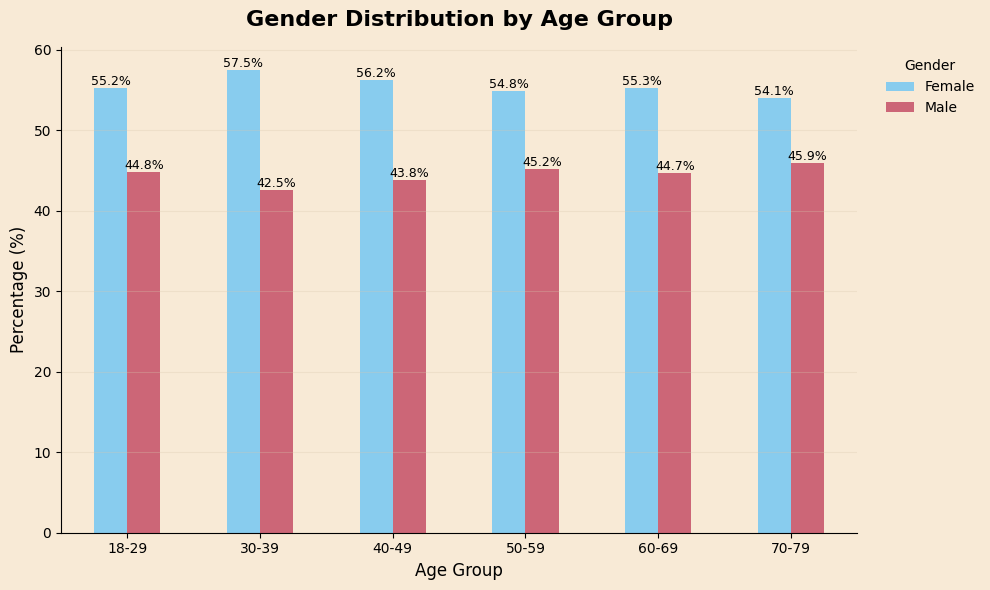

In [35]:
import seaborn as sns

# Create age groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[18,30,40,50,60,70,80,100],
    labels=[
        "18-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70-79",
        "80+"
    ]
)

# Calculate percentage of each gender within each age group
age_gender_pct = (
    pd.crosstab(
        df["age_group"],
        df["gender"].map(gender_labels),
        normalize="index"
    ) * 100
)
 # Plotting
ax = age_gender_pct.plot(
    kind="bar",
    figsize=(10,6),
    color=["#88CCEE", "#CC6677"]
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=9
    )

style_chart(
    title="Gender Distribution by Age Group",
    xlabel="Age Group",
    ylabel="Percentage (%)",
    legend_title="Gender"
)

plt.show()

## Ethnicity & Gender

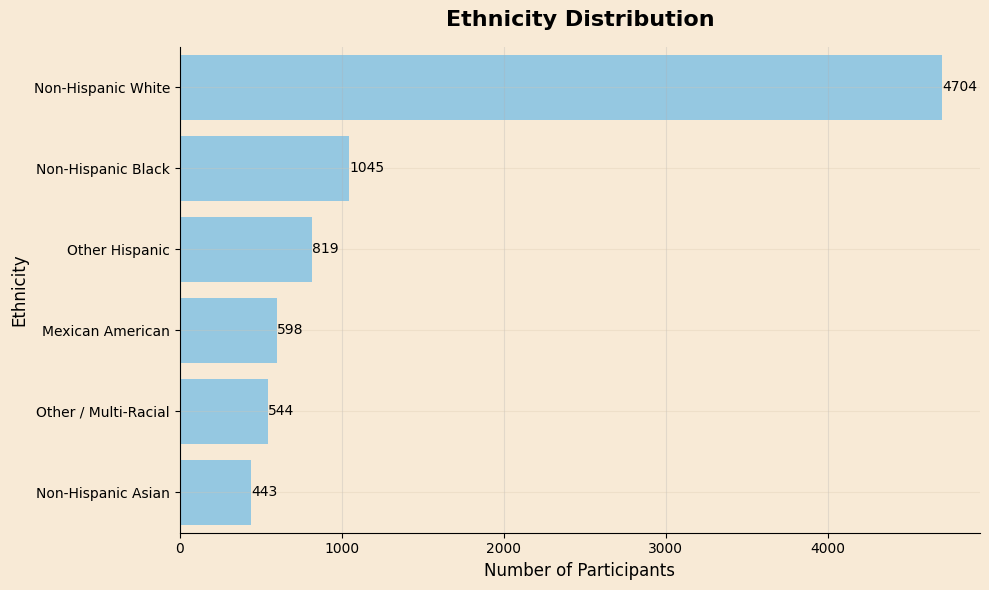

In [36]:
ethnicity_mapped = df["ethnicity"].map(ethnicity_labels)

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    y=ethnicity_mapped,
    order=ethnicity_mapped.value_counts().index,
    color="#88CCEE"
)

for container in ax.containers:
    ax.bar_label(container)

style_chart(
    title="Ethnicity Distribution",
    xlabel="Number of Participants",
    ylabel="Ethnicity"
)

plt.grid(axis="x", alpha=0.3)

plt.show()

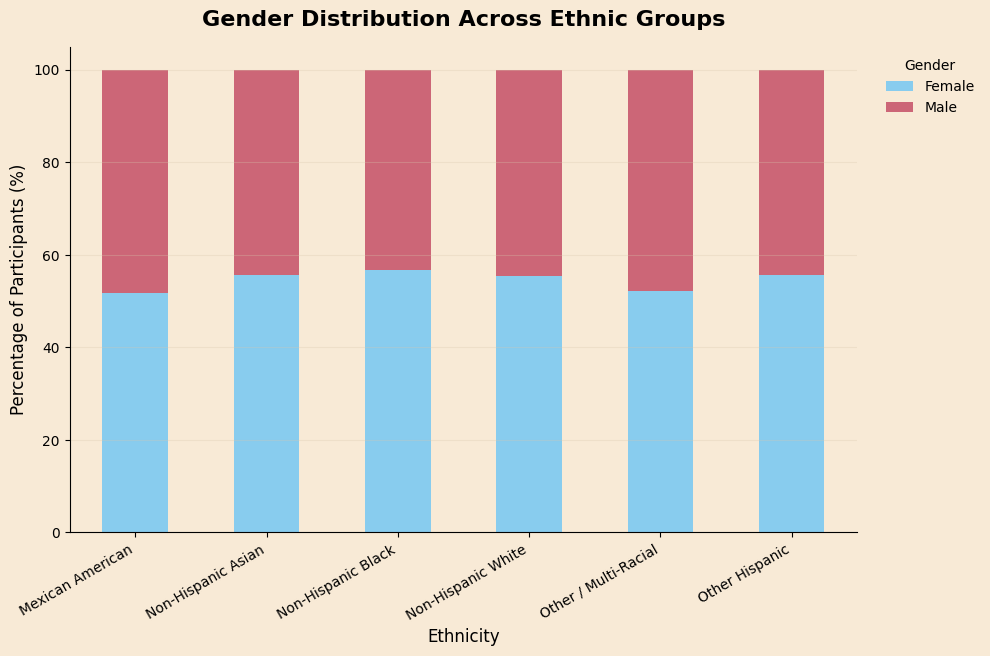

In [37]:
eth_gender = (
    pd.crosstab(
        df["ethnicity"].map(ethnicity_labels),
        df["gender"].map(gender_labels),
        normalize="index"
    ) * 100
)

ax = eth_gender.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["#88CCEE", "#CC6677"]
)

style_chart(
    title="Gender Distribution Across Ethnic Groups",
    xlabel="Ethnicity",
    ylabel="Percentage of Participants (%)",
    legend_title="Gender",
    grid_axis="y"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.show()

## Body Mass Index


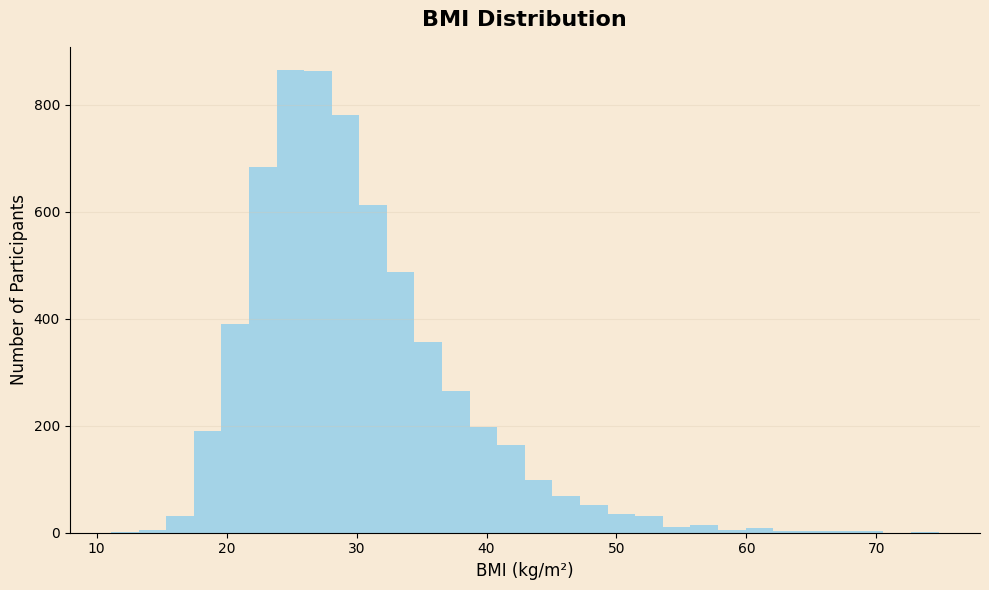

In [ ]:
# histogram of BMI distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="bmi",
    bins=30,
    color="#88CCEE",
    linewidth=0
)

style_chart(
    title="BMI Distribution",
    xlabel="BMI (kg/m²)",
    ylabel="Number of Participants",
    grid_axis="y"
)

plt.show()

In [ ]:
#statistical summary of BMI variable
df["bmi"].describe()

count    6235.000000
mean       29.659326
std         7.395826
min        11.100000
25%        24.500000
50%        28.300000
75%        33.400000
max        74.800000
Name: bmi, dtype: float64

In [ ]:
# Identify top 10 highest BMI values, which may indicate outliers or extreme cases in the dataset, elevating the mean and skewing the distribution, thus warranting further investigation or potential data cleaning steps to ensure accurate analysis and modeling outcomes.
df["bmi"].sort_values(ascending=False).head(10)

3533    74.8
1105    69.9
3276    69.1
2721    68.9
2678    68.5
6698    67.8
3060    67.1
432     66.5
4903    65.2
3366    64.7
Name: bmi, dtype: float64

In [ ]:
# Create BMI categories based on standard thresholds for underweight, normal weight, overweight, and obesity, allowing for analysis of the distribution of participants across these categories and their potential associations with health outcomes in the dataset.

df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ]
)
# Calculate the percentage of participants in each BMI category to understand the distribution of weight status in the population, which can provide insights into potential health risks and inform targeted interventions for weight management and obesity prevention.

(
    df["bmi_category"]
    .value_counts(normalize=True)
    .mul(100)
)

bmi_category
Obese          40.000000
Overweight     31.259022
Normal         26.880513
Underweight     1.860465
Name: proportion, dtype: float64

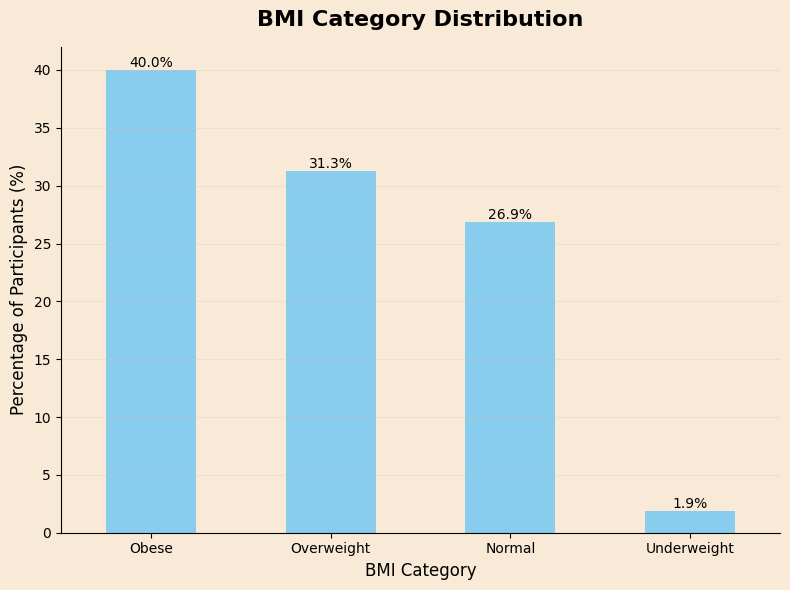

In [ ]:
# Plot the distribution of BMI categories to visualize the proportion of participants in each weight status category, which can help identify potential public health concerns related to overweight and obesity in the population.

bmi_pct = (
    df["bmi_category"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

ax = bmi_pct.plot(
    kind="bar",
    figsize=(8, 6),
    color="#88CCEE"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

style_chart(
    title="BMI Category Distribution",
    xlabel="BMI Category",
    ylabel="Percentage of Participants (%)",
    grid_axis="y",
    rotation=0
)

plt.show()

## Smoking

In [ ]:
# Explore smoking-related variables to understand the prevalence of smoking behaviors in the population, which can have significant implications for health outcomes and risk factors in the dataset.
[col for col in df.columns if "smok" in col.lower()]

['smoked_100_cigs?', 'smoker_now?']

In [41]:
df["smoking_status"] = pd.Series(pd.NA, index=df.index, dtype="object")

df.loc[df["smoked_100_cigs?"] == 2, "smoking_status"] = "Never"

df.loc[df["smoker_now?"] == 3, "smoking_status"] = "Former"

df.loc[df["smoker_now?"] == 2, "smoking_status"] = "Current Some Days"

df.loc[df["smoker_now?"] == 1, "smoking_status"] = "Current Every Day"

df["smoking_status"].value_counts(dropna=False)

smoking_status
Never                3810
<NA>                 1825
Former               1597
Current Every Day     741
Current Some Days     180
Name: count, dtype: int64

In [42]:
smoking_df = df[df["smoking_status"].notna()].copy()

In [163]:
smoking_score_map = {
    "Never": 0,
    "Former": 1,
    "Current Some Days": 2,
    "Current Every Day": 3
}

df["smoking_score"] = df["smoking_status"].map(smoking_score_map)
smoking_df["smoking_score"] = smoking_df["smoking_status"].map(smoking_score_map)

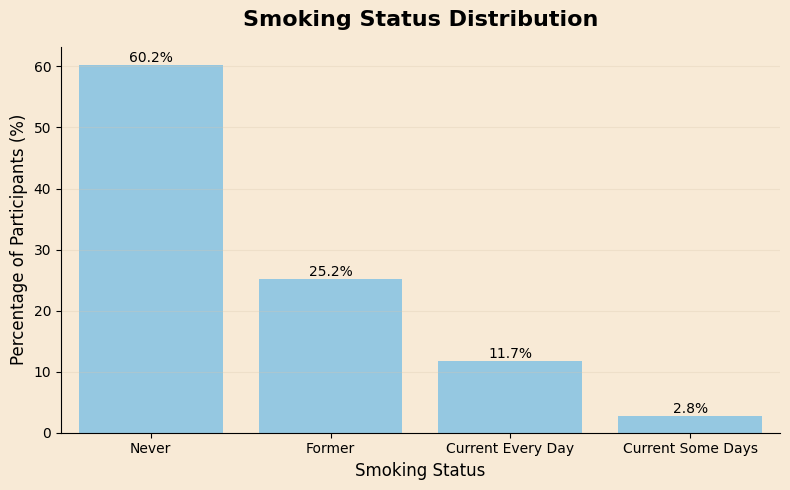

In [46]:
# Smoking status distribution (%)

smoking_distribution = (
    smoking_df["smoking_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reindex([
        "Never",
        "Former",
        "Current Every Day",
        "Current Some Days"
    ])
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=smoking_distribution.index,
    y=smoking_distribution.values,
    color="#88CCEE"
)

style_chart(
    title="Smoking Status Distribution",
    xlabel="Smoking Status",
    ylabel="Percentage of Participants (%)"
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=10
    )

plt.show()
plt.show()

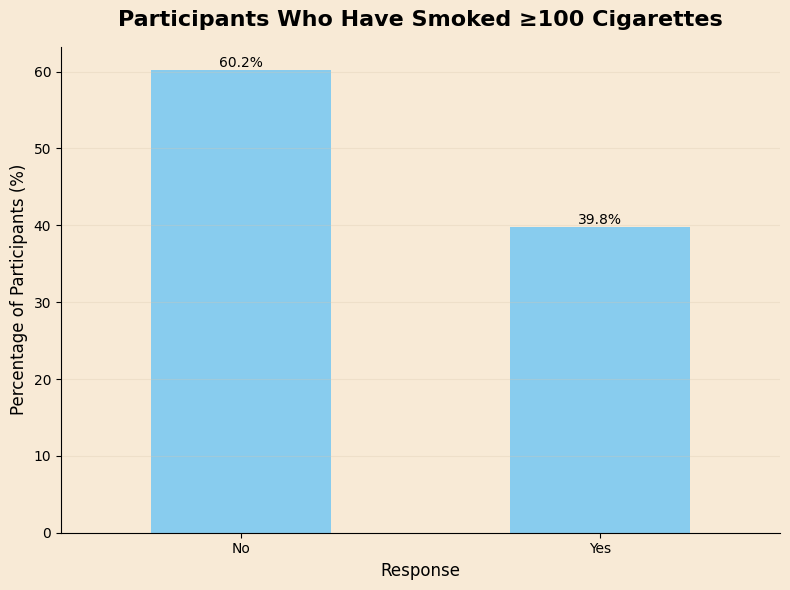

In [ ]:

# Calculate the percentage of participants who have smoked ≥100 cigarettes in their lifetime to understand the prevalence of significant smoking history in the population, which can be an important risk factor for various health conditions and may inform public health interventions and smoking cessation programs.
ever_smoked_pct = (
    df["smoked_100_cigs?"]
    .map(smoked_100_cigs_labels)
    .value_counts(normalize=True)
    .mul(100)
)

ax = ever_smoked_pct.plot(
    kind="bar",
    figsize=(8, 6),
    color="#88CCEE"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

style_chart(
    title="Participants Who Have Smoked ≥100 Cigarettes",
    xlabel="Response",
    ylabel="Percentage of Participants (%)"
)

plt.show()

## Diabetes

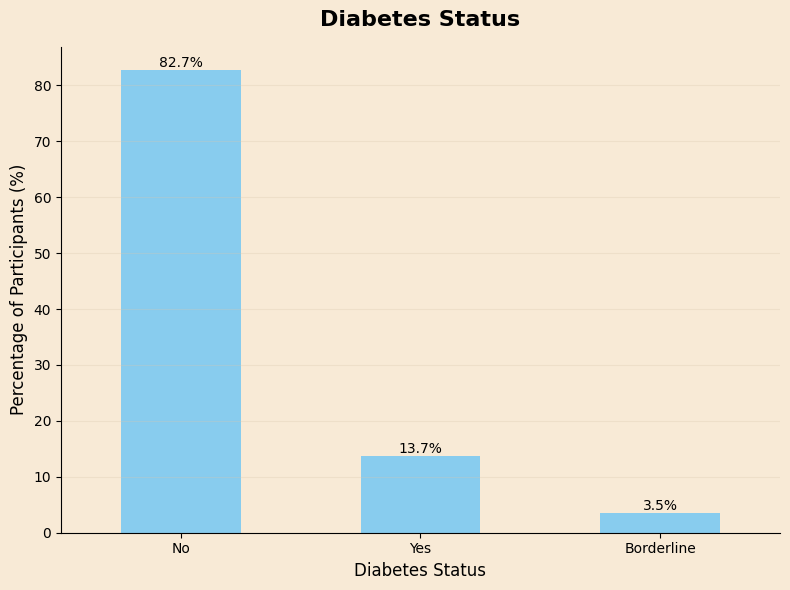

In [47]:
# Calculate the percentage of participants with diabetes to understand the prevalence of diabetes in the population, which is a critical health condition that can have significant implications for morbidity and mortality, and may inform public health strategies for diabetes prevention and management.
diabetes_pct = (
    df["diabetes?"]
    .map(diabetes_labels)
    .value_counts(normalize=True)
    .mul(100)
)

ax = diabetes_pct.plot(
    kind="bar",
    figsize=(8, 6),
    color="#88CCEE"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

style_chart(
    title="Diabetes Status",
    xlabel="Diabetes Status",
    ylabel="Percentage of Participants (%)"
)

plt.show()

## Blood Pressure

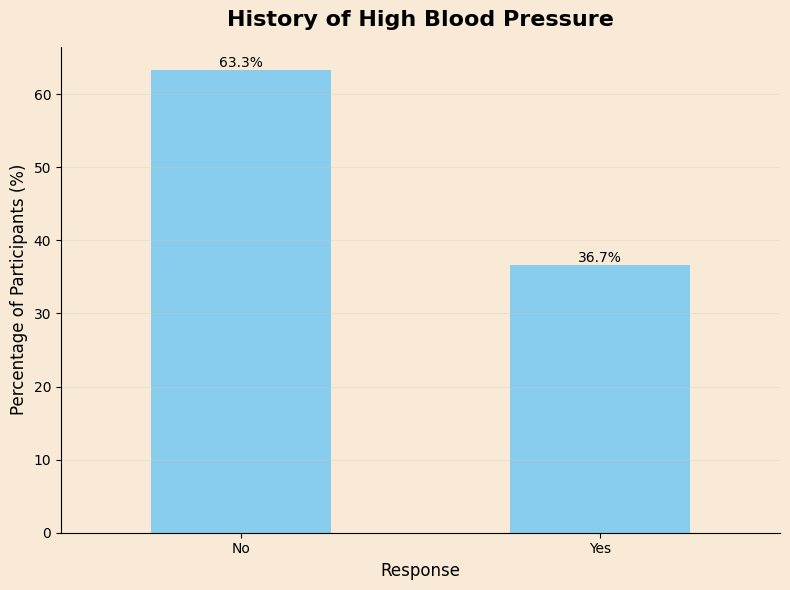

In [ ]:

# Calculate the percentage of participants with a history of high blood pressure to understand the prevalence of hypertension in the population, which is a major risk factor for cardiovascular diseases and can inform public health initiatives for blood pressure management and prevention.
bp_pct = (
    df["high_bp?"]
    .map(high_bp_labels)
    .value_counts(normalize=True)
    .mul(100)
)

ax = bp_pct.plot(
    kind="bar",
    figsize=(8, 6),
    color="#88CCEE"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

style_chart(
    title="History of High Blood Pressure",
    xlabel="Response",
    ylabel="Percentage of Participants (%)"
)

plt.show()

## Alcohol

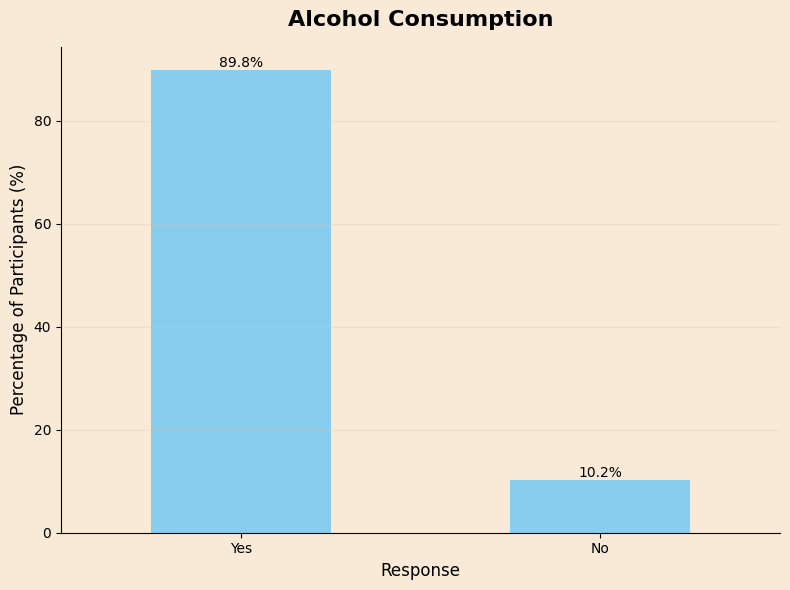

In [ ]:
# 
alc_pct = (
    df["alc_consum?"]
    .map(alc_consum_labels)
    .value_counts(normalize=True)
    .mul(100)
)

ax = alc_pct.plot(
    kind="bar",
    figsize=(8, 6),
    color="#88CCEE"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

style_chart(
    title="Alcohol Consumption",
    xlabel="Response",
    ylabel="Percentage of Participants (%)"
)

plt.show()

In [ ]:
# Map alcohol frequency values to descriptive categories
alcohol_freq_map = {
    0: "Never",
    1: "Daily / Near daily",
    2: "Daily / Near daily",
    3: "Weekly",
    4: "Weekly",
    5: "Weekly",
    6: "Monthly",
    7: "Monthly",
    8: "Few times/year",
    9: "Few times/year",
    10: "Few times/year"
}

df["alcohol_frequency_group"] = df["avg_drink_day_12m"].map(alcohol_freq_map)

In [ ]:
# Calculate the percentage of participants in each alcohol consumption frequency category to understand the distribution of drinking behaviors in the population, which can have important implications for public health and inform targeted interventions for alcohol use reduction and harm prevention.
df["alcohol_frequency_group"].value_counts()

alcohol_frequency_group
Daily / Near daily    2657
Weekly                1066
Monthly                158
Few times/year          92
Name: count, dtype: int64

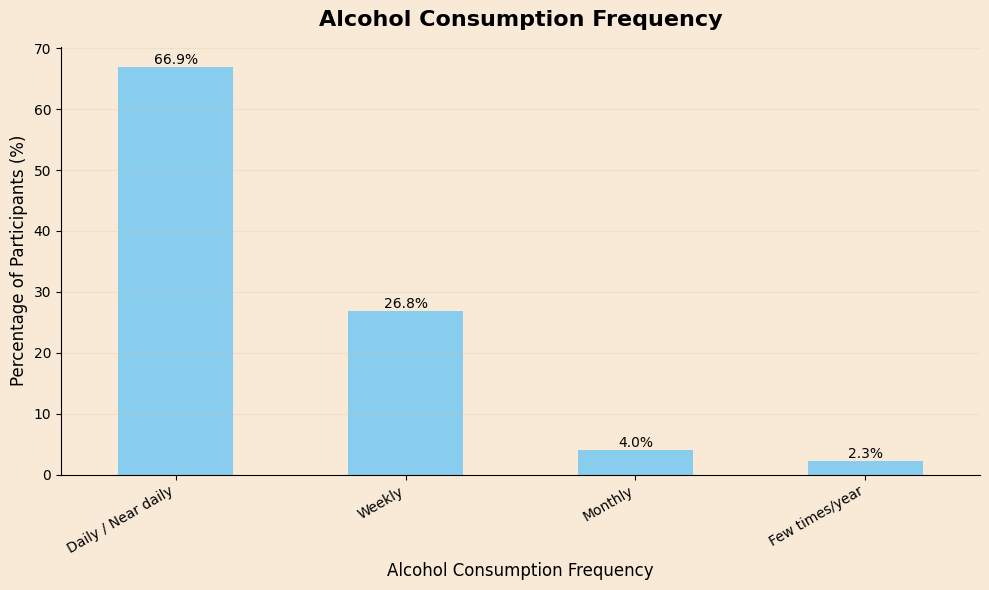

In [ ]:
# Calculate the percentage of participants in each alcohol consumption frequency category to understand the distribution of drinking behaviors in the population, which can have important implications for public health and inform targeted interventions for alcohol use reduction and harm prevention.
alcohol_order = [
    "Never",
    "Few times/year",
    "Monthly",
    "Weekly",
    "Daily / Near daily"
]

alcohol_pct = (
    df["alcohol_frequency_group"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

ax = alcohol_pct.plot(
    kind="bar",
    figsize=(10, 6),
    color="#88CCEE"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

style_chart(
    title="Alcohol Consumption Frequency",
    xlabel="Alcohol Consumption Frequency",
    ylabel="Percentage of Participants (%)",
    rotation=30
)

plt.show()

In [ ]:
# Rename the 'avg_drink_day_12m' column to 'alcohol_frequency_12m' for better clarity and consistency in the dataset, as it more accurately reflects the content of the variable and enhances readability for analysis and interpretation.

df = df.rename(columns={
    "avg_drink_day_12m": "alcohol_frequency_12m"
})

## BMI and CRP Comparisons

In [172]:
# Explore relationship between BMI category and CRP levels (median CRP by BMI category)

df.groupby(
    "bmi_category",
    observed=True
)["crp_mg/l"].median()

bmi_category
Underweight    0.610
Normal         0.850
Overweight     1.505
Obese          3.450
Name: crp_mg/l, dtype: float64

In [173]:
# Explore relationship between BMI category and CRP levels (mean CRP by BMI category)
df.groupby(
    "bmi_category",
    observed=True
)["crp_mg/l"].mean()

bmi_category
Underweight    2.883297
Normal         2.049195
Overweight     2.894730
Obese          5.775626
Name: crp_mg/l, dtype: float64

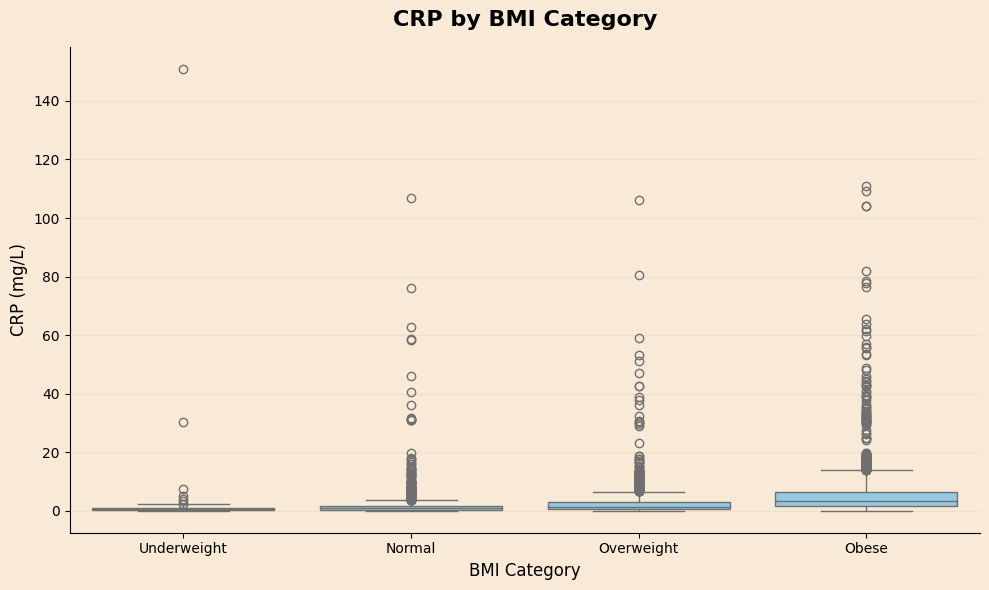

In [174]:
# Visualize relationship between BMI category and CRP levels using boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="bmi_category",
    y="crp_mg/l",
    color="#88CCEE"
)

style_chart(
    title="CRP by BMI Category",
    xlabel="BMI Category",
    ylabel="CRP (mg/L)"
)

plt.show()

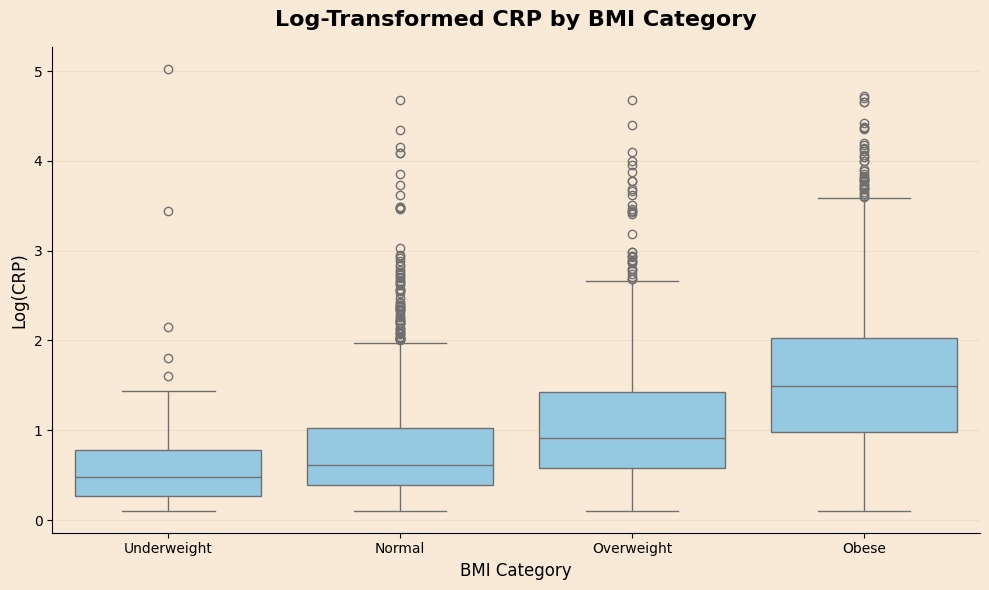

In [175]:
import numpy as np

# Since CRP is often right-skewed, we can log-transform it for better visualization
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["bmi_category"],
    y=np.log1p(df["crp_mg/l"]),
    color="#88CCEE"
)

style_chart(
    title="Log-Transformed CRP by BMI Category",
    xlabel="BMI Category",
    ylabel="Log(CRP)"
)

plt.show()

In [ ]:
# Log-transform CRP values to reduce skewness and improve the distribution for analysis, which can help in identifying patterns and relationships with other variables such as BMI category more effectively.
import numpy as np

df["log_crp"] = np.log1p(df["crp_mg/l"])

In [177]:
# Calculate median log-transformed CRP by BMI category, which can be more robust to outliers than the mean
df.groupby(
    "bmi_category",
    observed=True
)["log_crp"].median()

bmi_category
Underweight    0.476234
Normal         0.615186
Overweight     0.918287
Obese          1.492904
Name: log_crp, dtype: float64

In [3]:
# Calculate correlation between BMI and CRP levels

df[["bmi", "crp_mg/l"]].corr(method="spearman")

,bmi,crp_mg/l
bmi,1.000000,0.510157
crp_mg/l,0.510157,1.000000


## BMI and NLR (Neurophil to Lymphocyte Ratio)

In [179]:
# Explore relationship between BMI category and NLR (median NLR by BMI category)
df.groupby(
    "bmi_category",
    observed=True
)["nlr"].median()

bmi_category
Underweight    2.055556
Normal         1.937500
Overweight     1.947368
Obese          2.040000
Name: nlr, dtype: float64

In [180]:
# Explore relationship between BMI category and NLR (median NLR by BMI category)
df.groupby(
    "bmi_category",
    observed=True
)["nlr"].mean()

bmi_category
Underweight    2.174942
Normal         2.230376
Overweight     2.220544
Obese          2.274025
Name: nlr, dtype: float64

In [4]:
# Calculate correlation between BMI and NLR levels
df[["bmi", "nlr"]].corr(method="spearman")

,bmi,nlr
bmi,1.000000,0.058625
nlr,0.058625,1.000000


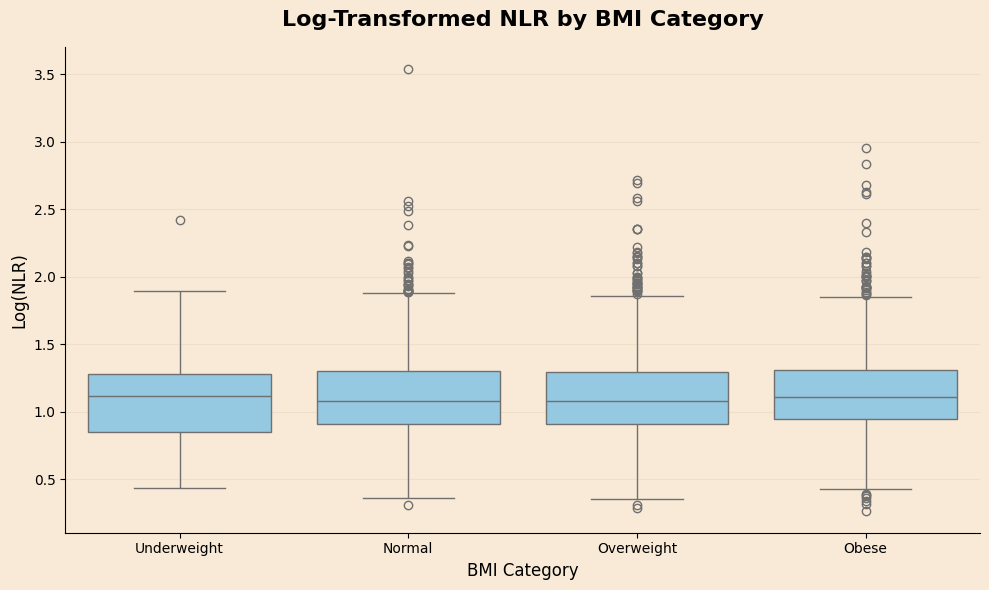

In [182]:
import numpy as np
# Since NLR is often right-skewed, we can log-transform it for better visualization
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["bmi_category"],
    y=np.log1p(df["nlr"]),
    color="#88CCEE"
)

style_chart(
    title="Log-Transformed NLR by BMI Category",
    xlabel="BMI Category",
    ylabel="Log(NLR)"
)

plt.show()

In [ ]:
# Log-transform NLR values to reduce skewness and improve the distribution for analysis, which can help in identifying patterns and relationships with other variables such as BMI category more effectively.
df["log_nlr"] = np.log1p(df["nlr"])

In [ ]:
# Calculate median log-transformed NLR by BMI category, which can be more robust to outliers than the mean
df.groupby(
    "bmi_category",
    observed=True
)["log_nlr"].median()

bmi_category
Underweight    1.116961
Normal         1.077559
Overweight     1.080913
Obese          1.111858
Name: log_nlr, dtype: float64

In [5]:
# Calculate correlation between waist-hip ratio and CRP levels
df[["waist_hip_ratio", "crp_mg/l"]].corr(method="spearman")

,waist_hip_ratio,crp_mg/l
waist_hip_ratio,1.000000,0.222245
crp_mg/l,0.222245,1.000000


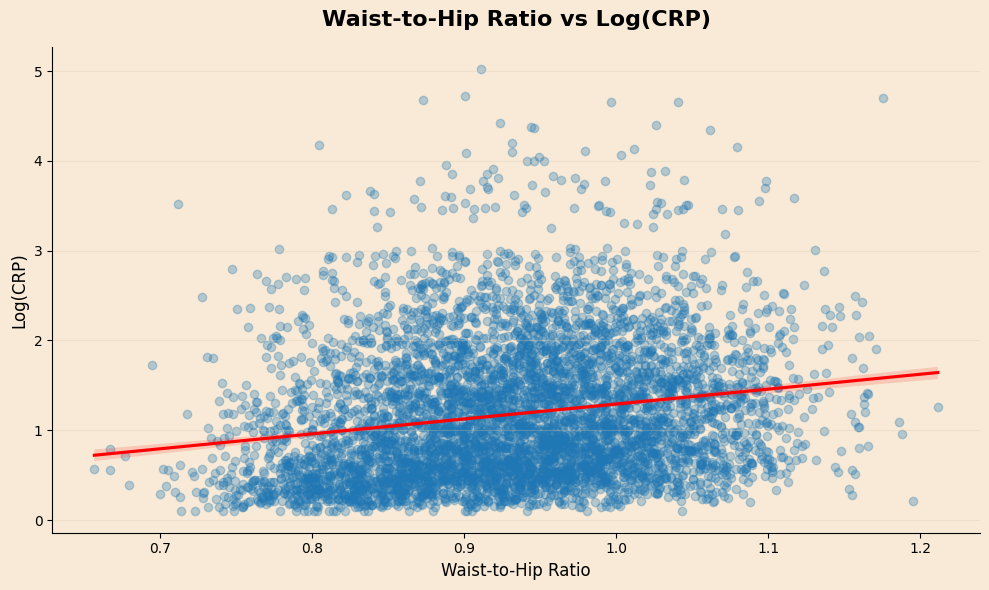

In [186]:
# Visualize relationship between waist-hip ratio and CRP levels using scatterplot

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="waist_hip_ratio",
    y="log_crp",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

style_chart(
    title="Waist-to-Hip Ratio vs Log(CRP)",
    xlabel="Waist-to-Hip Ratio",
    ylabel="Log(CRP)"
)

plt.show()

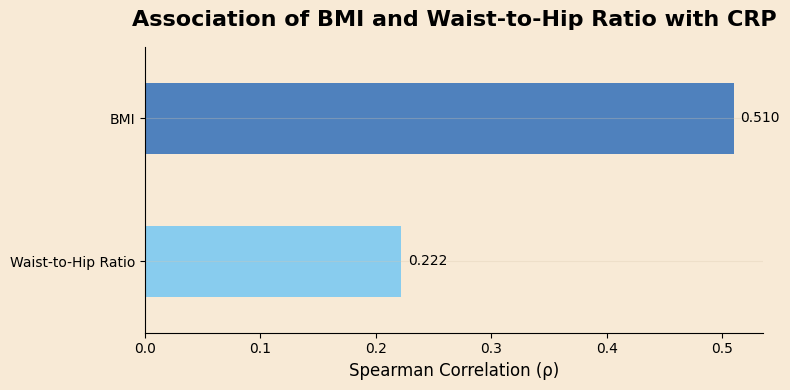

In [ ]:
# Plot the correlation of BMI and waist-to-hip ratio with CRP levels to compare the strength of association between these two measures of adiposity and inflammation, which can provide insights into the relative importance of overall obesity (BMI) versus central obesity (waist-to-hip ratio) in relation to inflammatory status in the population.
# Spearman correlation is used here because CRP is not normally distributed and may have outliers, making it a more appropriate measure of association for these variables.
corr_df = pd.DataFrame({
    "Measure": [
        "BMI",
        "Waist-to-Hip Ratio"
    ],
    "Correlation with CRP": [
        df[["bmi", "crp_mg/l"]]
            .corr(method="spearman")
            .iloc[0,1],

        df[["waist_hip_ratio", "crp_mg/l"]]
            .corr(method="spearman")
            .iloc[0,1]
    ]
})

ax = corr_df.plot(
    x="Measure",
    y="Correlation with CRP",
    kind="barh",
    figsize=(8,4),
    color=["#4F81BD", "#88CCEE"],
    legend=False
)

ax.invert_yaxis()

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=5
    )

style_chart(
    title="Association of BMI and Waist-to-Hip Ratio with CRP",
    xlabel="Spearman Correlation (ρ)",
    ylabel=""
)

plt.show()

## Smoking effect on WBC count  

Apparent missing values in the current smoking variable were investigated and found to result from questionnaire skip logic. A new smoking status variable was created by combining lifetime smoking history and current smoking behaviour, allowing participants to be classified as never, former, occasional, or daily smokers.

In [ ]:
# Count the occurrences of each category in the 'smoker_now?' column to understand the distribution of current smoking status among participants, which can provide insights into smoking behaviors and potential health risks in the population.
print(df['smoker_now?'].value_counts(dropna=False))

smoker_now?
NaN    5635
3.0    1597
1.0     741
2.0     180
Name: count, dtype: int64


In [53]:
# Calculate the percentage of missing values in the 'smoker_now?' column to assess the extent of missing data for current smoking status, which can impact the analysis and interpretation of smoking-related variables in the dataset.
print(df["smoker_now?"].isna().mean() * 100)
print(df["smoked_100_cigs?"].value_counts(dropna=False))
print(df["smoker_now?"].unique())

69.11566294615479
smoked_100_cigs?
2.0    3810
1.0    2518
NaN    1818
9.0       4
7.0       3
Name: count, dtype: int64
[ 3. nan  1.  2.]


In [190]:
#create smoking status variable based on smoking history and current smoking status questions

df["smoking_status"] = pd.NA
df["smoking_status"] = df["smoking_status"].astype("object")

df.loc[df["smoked_100_cigs?"] == 2, "smoking_status"] = "Never"
df.loc[df["smoker_now?"] == 3, "smoking_status"] = "Former"
df.loc[df["smoker_now?"] == 2, "smoking_status"] = "Current Some Days"
df.loc[df["smoker_now?"] == 1, "smoking_status"] = "Current Every Day"

df["smoking_status"].value_counts(dropna=False)

smoking_status
Never                3810
<NA>                 1825
Former               1597
Current Every Day     741
Current Some Days     180
Name: count, dtype: int64

In [ ]:
# Create a subset of the dataframe that includes only participants with non-missing smoking status to facilitate analysis of smoking-related variables and their associations with health outcomes in the dataset.
smoking_df = df[df["smoking_status"].notna()]

In [192]:
# Calculate median WBC count by current smoking status
wbc_median = smoking_df.groupby(
    "smoking_status",
    observed=True
)["wbc_abs."].median()

wbc_median

smoking_status
Current Every Day    7.60
Current Some Days    7.15
Former               6.70
Never                6.40
Name: wbc_abs., dtype: float64

In [193]:
# Calculate mean WBC count by current smoking status
wbc_mean = smoking_df.groupby(
    "smoking_status",
    observed=True
)["wbc_abs."].mean()

wbc_mean

smoking_status
Current Every Day    7.874891
Current Some Days    7.416071
Former               6.963827
Never                6.684679
Name: wbc_abs., dtype: float64

In [54]:
# Calculate percentage difference in median WBC count compared to never smokers

wbc_median = (
    smoking_df.groupby(
        "smoking_status",
        observed=True
    )["wbc_abs."]
    .median()
    .reindex([
        "Never",
        "Former",
        "Current Some Days",
        "Current Every Day"
    ])
)

(
    (wbc_median - wbc_median["Never"])
    / wbc_median["Never"]
    * 100
).round(1)

smoking_status
Never                 0.0
Former                4.7
Current Some Days    11.7
Current Every Day    18.7
Name: wbc_abs., dtype: float64

In [55]:
# Calculate percentage difference in mean WBC count compared to never smokers

wbc_mean = (
    smoking_df.groupby(
        "smoking_status",
        observed=True
    )["wbc_abs."]
    .mean()
    .reindex([
        "Never",
        "Former",
        "Current Some Days",
        "Current Every Day"
    ])
)

(
    (wbc_mean - wbc_mean["Never"])
    / wbc_mean["Never"]
    * 100
).round(1)

smoking_status
Never                 0.0
Former                4.2
Current Some Days    10.9
Current Every Day    17.8
Name: wbc_abs., dtype: float64

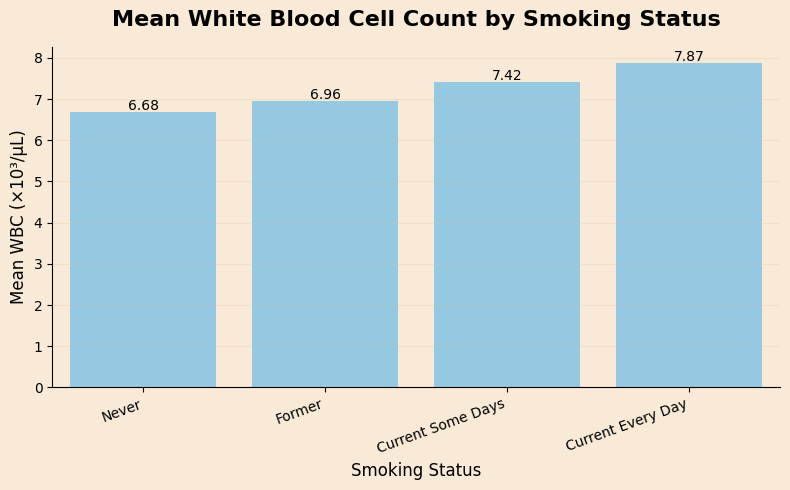

In [56]:
# Visualize mean WBC count by smoking status using bar plot

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=wbc_mean.index,
    y=wbc_mean.values,
    color="#88CCEE"
)

# Add values on top
for i, value in enumerate(wbc_mean.values):
    plt.text(
        i,
        value + 0.05,
        f"{value:.2f}",
        ha="center",
        fontsize=10
    )

style_chart(
    title="Mean White Blood Cell Count by Smoking Status",
    xlabel="Smoking Status",
    ylabel="Mean WBC (×10³/µL)",
    rotation=20
)

plt.show()

In [59]:
# Create summary DataFrame combining median and mean WBC counts by smoking status, along with percentage increase compared to never smokers

summary = pd.DataFrame({
    "Median WBC": wbc_median,
    "Mean WBC": wbc_mean

})

summary["% Increase vs Never Smokers Median"] = (
    (summary["Median WBC"] - summary.loc["Never", "Median WBC"])
    / summary.loc["Never", "Median WBC"]
    * 100
).round(1)

summary

,Median WBC,Mean WBC,% Increase vs Never Smokers Median
smoking_status,,,
Never,6.40,6.684679,0.0
Former,6.70,6.963827,4.7
Current Some Days,7.15,7.416071,11.7
Current Every Day,7.60,7.874891,18.7


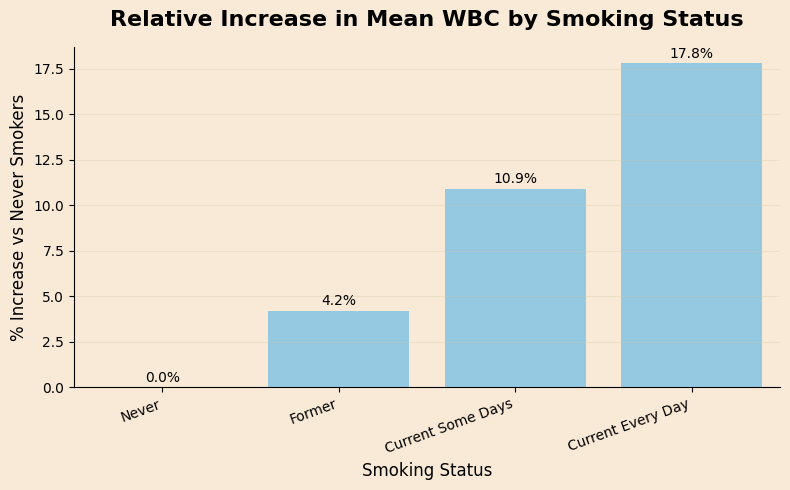

In [ ]:
# Visualize relative increase in mean WBC count by smoking status compared to never smokers
wbc_increase = (
    (wbc_mean - wbc_mean["Never"])
    / wbc_mean["Never"]
    * 100
).round(1)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=wbc_increase.index,
    y=wbc_increase.values,
    color="#88CCEE"
)

for i, value in enumerate(wbc_increase.values):
    plt.text(
        i,
        value + 0.3,
        f"{value:.1f}%",
        ha="center",
        fontsize=10
    )

style_chart(
    title="Relative Increase in Mean WBC by Smoking Status",
    xlabel="Smoking Status",
    ylabel="% Increase vs Never Smokers",
    rotation=20
)

plt.show()

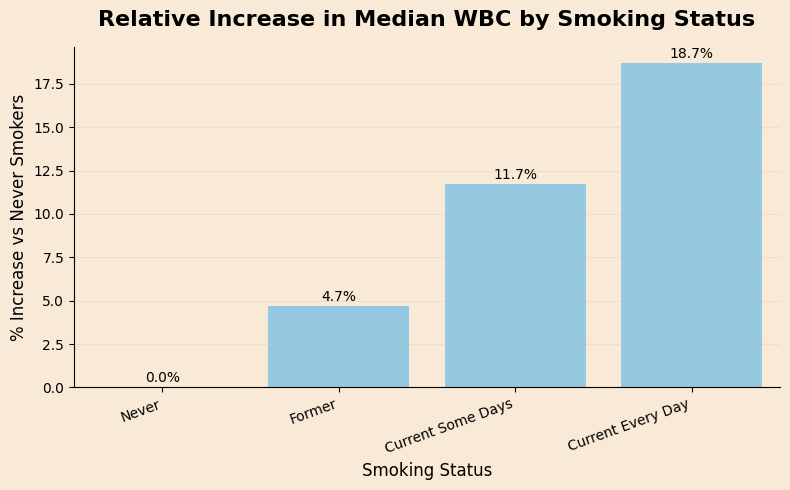

In [61]:
wbc_increase = (
    (wbc_median - wbc_median["Never"])
    / wbc_median["Never"]
    * 100
).round(1)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=wbc_increase.index,
    y=wbc_increase.values,
    color="#88CCEE"
)

for i, value in enumerate(wbc_increase.values):
    plt.text(
        i,
        value + 0.3,
        f"{value:.1f}%",
        ha="center",
        fontsize=10
    )

style_chart(
    title="Relative Increase in Median WBC by Smoking Status",
    xlabel="Smoking Status",
    ylabel="% Increase vs Never Smokers",
    rotation=20
)

plt.show()

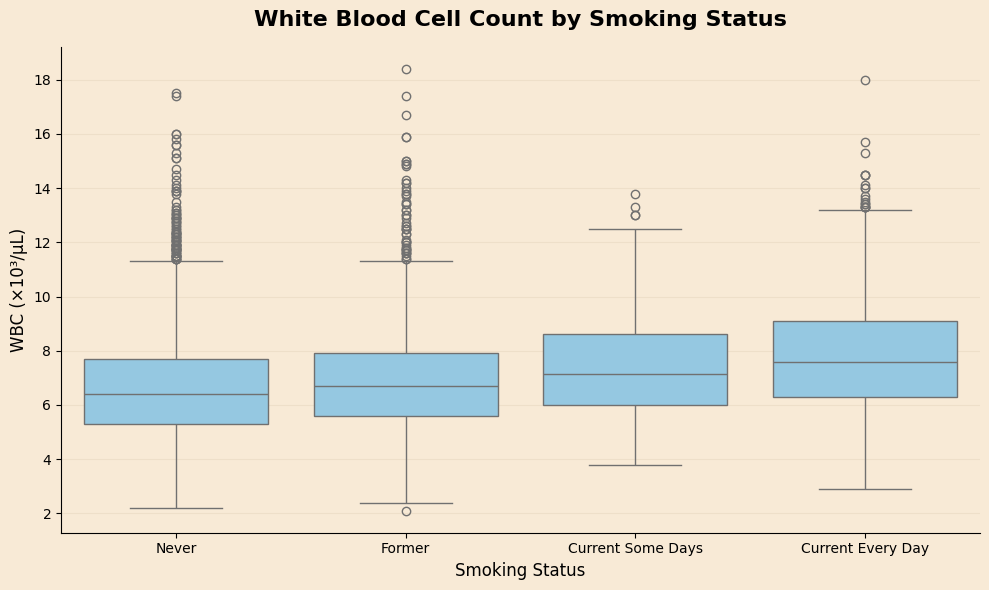

In [201]:
# Visualize distribution of WBC counts by smoking status using boxplot

smoking_order = [
    "Never",
    "Former",
    "Current Some Days",
    "Current Every Day"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=smoking_df,
    x="smoking_status",
    y="wbc_abs.",
    order=smoking_order,
    color="#88CCEE"
)

style_chart(
    title="White Blood Cell Count by Smoking Status",
    xlabel="Smoking Status",
    ylabel="WBC (×10³/µL)"
)

plt.show()

## Neutrophils by Smoking


In [202]:
# Calculate median neutrophil count by smoking status
neut_median = smoking_df.groupby(
    "smoking_status",
    observed=True
)["neutrophils_abs."].median().sort_values()

neut_median

smoking_status
Never                3.7
Former               4.0
Current Some Days    4.1
Current Every Day    4.5
Name: neutrophils_abs., dtype: float64

In [ ]:
# Calculate mean neutrophil count by smoking status
neut_mean = smoking_df.groupby(
    "smoking_status",
    observed=True
)["neutrophils_abs."].mean().sort_values()
neut_mean

smoking_status
Never                3.944281
Former               4.209974
Current Some Days    4.422619
Current Every Day    4.759091
Name: neutrophils_abs., dtype: float64

In [204]:
# Calculate median neutrophil count by smoking status
summary = pd.DataFrame({
    "Median Neutrophils": neut_median,

})

summary["% Increase vs Never Smokers"] = (
    (summary["Median Neutrophils"] - summary.loc["Never", "Median Neutrophils"])
    / summary.loc["Never", "Median Neutrophils"]
    * 100
).round(1)

summary

,Median Neutrophils,% Increase vs Never Smokers
smoking_status,,
Never,3.7,0.0
Former,4.0,8.1
Current Some Days,4.1,10.8
Current Every Day,4.5,21.6


In [205]:
# calculate mean neutrophil count by smoking status
summary = pd.DataFrame({
    "Mean Neutrophils": neut_mean,

})

summary["% Increase vs Never Smokers"] = (
    (summary["Mean Neutrophils"] - summary.loc["Never", "Mean Neutrophils"])
    / summary.loc["Never", "Mean Neutrophils"]
    * 100
).round(1)

summary

,Mean Neutrophils,% Increase vs Never Smokers
smoking_status,,
Never,3.944281,0.0
Former,4.209974,6.7
Current Some Days,4.422619,12.1
Current Every Day,4.759091,20.7


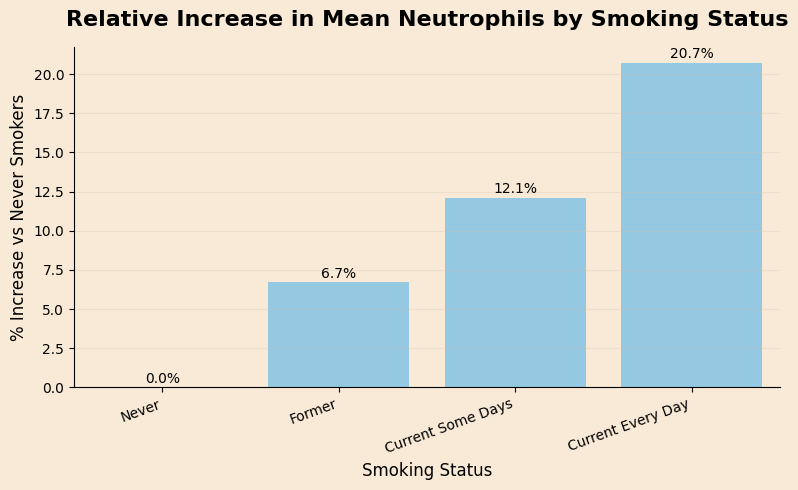

In [206]:
# Visualize relative increase in mean neutrophil count by smoking status compared to never smokers

neutrophil_increase = (
    (neut_mean - neut_mean["Never"])
    / neut_mean["Never"]
    * 100
).round(1)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=neutrophil_increase.index,
    y=neutrophil_increase.values,
    color="#88CCEE"
)

for i, value in enumerate(neutrophil_increase.values):
    plt.text(
        i,
        value + 0.3,
        f"{value:.1f}%",
        ha="center",
        fontsize=10
    )

style_chart(
    title="Relative Increase in Mean Neutrophils by Smoking Status",
    xlabel="Smoking Status",
    ylabel="% Increase vs Never Smokers",
    rotation=20
)

plt.show()

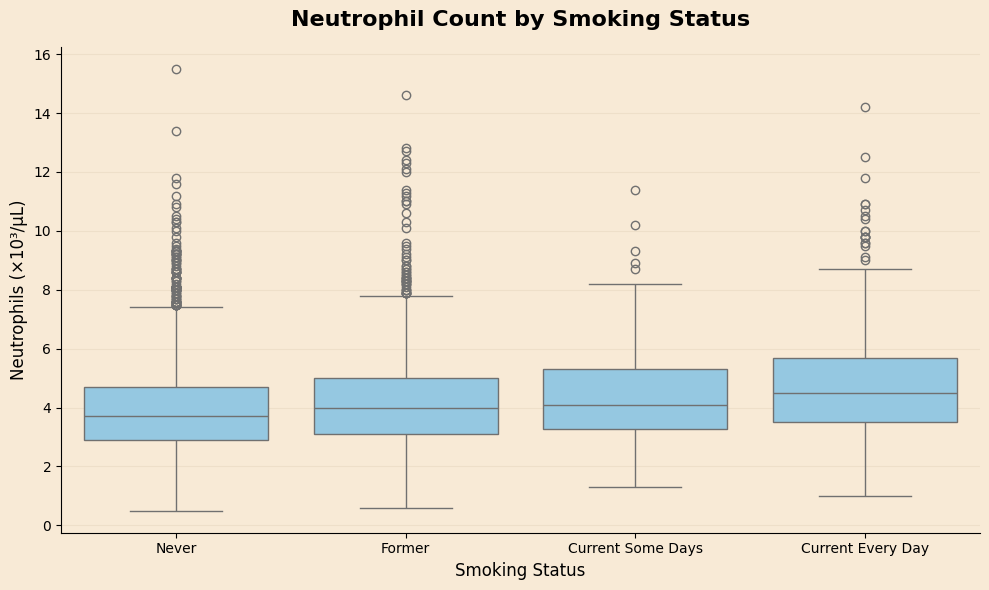

In [207]:
# Visualize distribution of neutrophil counts by smoking status using boxplot

smoking_order = [
    "Never",
    "Former",
    "Current Some Days",
    "Current Every Day"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=smoking_df,
    x="smoking_status",
    y="neutrophils_abs.",
    order=smoking_order,
    color="#88CCEE"
)

style_chart(
    title="Neutrophil Count by Smoking Status",
    xlabel="Smoking Status",
    ylabel="Neutrophils (×10³/µL)"
)

plt.show()

In [208]:
# Create summary DataFrame combining median and mean WBC and neutrophil counts by smoking status, along with percentage increase compared to never smokers

summary = pd.DataFrame({
    "Median WBC": wbc_median,
    "Median Neutrophils": neut_median
})

summary["WBC % Increase"] = (
    (summary["Median WBC"] - summary.loc["Never", "Median WBC"])
    / summary.loc["Never", "Median WBC"]
    * 100
).round(1)

summary["Neutrophils % Increase"] = (
    (summary["Median Neutrophils"] - summary.loc["Never", "Median Neutrophils"])
    / summary.loc["Never", "Median Neutrophils"]
    * 100
).round(1)

summary

,Median WBC,Median Neutrophils,WBC % Increase,Neutrophils % Increase
smoking_status,,,,
Never,6.40,3.7,0.0,0.0
Former,6.70,4.0,4.7,8.1
Current Some Days,7.15,4.1,11.7,10.8
Current Every Day,7.60,4.5,18.7,21.6


In [209]:

# Calculate Spearman correlation between smoking score and WBC count
from scipy.stats import spearmanr

temp = smoking_df[
    ["smoking_score", "wbc_abs."]
].dropna()

corr, p = spearmanr(
    temp["smoking_score"],
    temp["wbc_abs."]
)

print(f"Spearman r = {corr:.3f}")
print(f"p-value = {p:.4e}")
print(f"N = {len(temp)}")

Spearman r = 0.165
p-value = 4.7056e-38
N = 5995


## Haematocrit and Smoking

In [210]:
# Calculate median hematocrit percentage by smoking status

smoking_df.groupby(
    "smoking_status",
    observed=True
)["hct_%"].median()

smoking_status
Current Every Day    42.7
Current Some Days    42.4
Former               41.3
Never                40.9
Name: hct_%, dtype: float64

In [211]:
# Calcuate mean hematocrit percentage by smoking status
smoking_df.groupby(
    "smoking_status",
    observed=True
)["hct_%"].mean().round(1)

smoking_status
Current Every Day    42.4
Current Some Days    41.9
Former               41.2
Never                40.8
Name: hct_%, dtype: float64

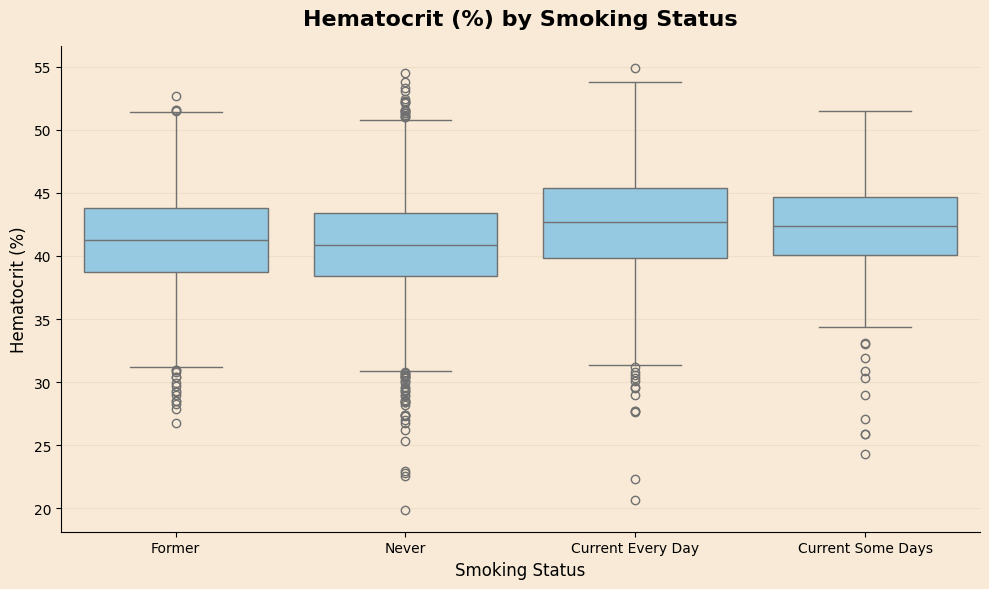

In [212]:
# Visualize distribution of hematocrit percentage by smoking status using boxplot

plt.figure(figsize=(10,6))

sns.boxplot(
    data=smoking_df,
    x="smoking_status",
    y="hct_%",
    color="#88CCEE"
)

style_chart(
    title="Hematocrit (%) by Smoking Status",
    xlabel="Smoking Status",
    ylabel="Hematocrit (%)"
)

plt.tight_layout()
plt.show()

In [ ]:

# median hematocrit percentage by smoking status, along with percentage increase compared to never smokers
hct_median = smoking_df.groupby(
    "smoking_status",
    observed=True
)["hct_%"].median()

hct_summary = pd.DataFrame({
    "Median Hematocrit (%)": hct_median
})

hct_summary["% Increase vs Non-Smoker"] = (
    (hct_summary["Median Hematocrit (%)"]
     - hct_summary.loc["Never", "Median Hematocrit (%)"])
    / hct_summary.loc["Never", "Median Hematocrit (%)"]
    * 100
).round(1)

hct_summary

,Median Hematocrit (%),% Increase vs Non-Smoker
smoking_status,,
Current Every Day,42.7,4.4
Current Some Days,42.4,3.7
Former,41.3,1.0
Never,40.9,0.0


## All Haematology and Smoking

In [214]:
# Create list of hematology-related columns for later use in correlation analysis and visualization
haem_cols = [
    "wbc_abs.",
    "neutrophils_abs.",
    "lymphocytes_abs.",
    "monocytes_abs.",
    "rbc",
    "haemoglobin_mmol/l",
    "hct_%",
    "mcv_fl",
    "mchpg",
    "mchcg/dl",
    "rdw%",
    "plt1000/μl",
    "mpvfl",
    "nlr"
]

In [215]:
# Calculate median and mean values for each hematology parameter by smoking status, along with percentage change compared to never smokers, and compile results into a summary DataFrame

results = []

for col in haem_cols:

    medians = smoking_df.groupby(
        "smoking_status",
        observed=True
    )[col].median()

    means = smoking_df.groupby(
        "smoking_status",
        observed=True
    )[col].mean()

    results.append({
        "Parameter": col,

        "Median Never": medians["Never"],
        "Median Former": medians["Former"],
        "Median Current Some Days": medians["Current Some Days"],
        "Median Current Every Day": medians["Current Every Day"],

        "Mean Never": means["Never"],
        "Mean Former": means["Former"],
        "Mean Current Some Days": means["Current Some Days"],
        "Mean Current Every Day": means["Current Every Day"],

        "% Change Median Current Every Day vs Never": (
            (medians["Current Every Day"] - medians["Never"])
            / medians["Never"] * 100
        ),

        "% Change Mean Current Every Day vs Never": (
            (means["Current Every Day"] - means["Never"])
            / means["Never"] * 100
        )
    })

smoking_haem_summary = pd.DataFrame(results)

smoking_haem_summary = (
    smoking_haem_summary
    .round(2)
    .sort_values("% Change Median Current Every Day vs Never", ascending=False)
)

smoking_haem_summary

,Parameter,Median Never,Median Former,Median Current Some Days,Median Current Every Day,Mean Never,Mean Former,Mean Current Some Days,Mean Current Every Day,% Change Median Current Every Day vs Never,% Change Mean Current Every Day vs Never
1,neutrophils_abs.,3.70,4.00,4.10,4.50,3.94,4.21,4.42,4.76,21.62,20.66
3,monocytes_abs.,0.50,0.50,0.50,0.60,0.52,0.56,0.58,0.60,20.00,13.84
0,wbc_abs.,6.40,6.70,7.15,7.60,6.68,6.96,7.42,7.87,18.75,17.81
2,lymphocytes_abs.,1.90,1.90,2.10,2.20,2.00,1.94,2.15,2.27,15.79,13.61
13,nlr,1.94,2.14,2.00,2.07,2.15,2.42,2.45,2.31,6.67,7.49
5,haemoglobin_mmol/l,8.57,8.69,8.85,9.00,8.55,8.63,8.76,8.91,5.07,4.21
6,hct_%,40.90,41.30,42.40,42.70,40.85,41.18,41.89,42.41,4.40,3.82
8,mchpg,29.90,30.30,30.30,30.80,29.69,30.12,29.88,30.54,3.01,2.85
10,rdw%,13.50,13.70,13.70,13.80,13.77,13.94,14.22,14.06,2.22,2.09
7,mcv_fl,88.60,89.50,89.85,90.40,88.07,89.25,88.69,90.24,2.03,2.46


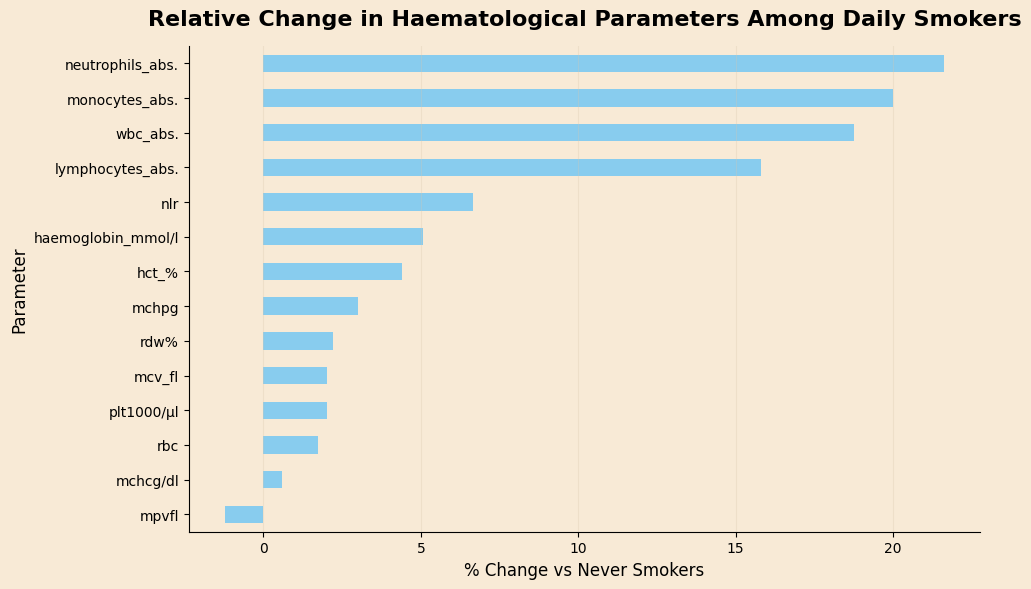

In [216]:
# Visualize relative change in median hematological parameters among daily smokers compared to never smokers

smoking_effects = (
    smoking_haem_summary
    .set_index("Parameter")["% Change Median Current Every Day vs Never"]
    .sort_values()
)

ax = smoking_effects.plot(
    kind="barh",
    figsize=(10,6),
    color="#88CCEE"
)

style_chart(
    title="Relative Change in Haematological Parameters Among Daily Smokers",
    xlabel="% Change vs Never Smokers",
    ylabel="Parameter",
    grid_axis="x"
)

plt.tight_layout()
plt.show()

In [ ]:
# Create a numerical score for each smoking status category (created a function for this in feature_engineering.py) to facilitate correlation analysis and modeling, where higher scores indicate more frequent smoking behavior, allowing for quantitative assessment of the relationship between smoking intensity and various health outcomes in the dataset.

smoking_score = {
    "Never": 0,
    "Former": 1,
    "Current Some Days": 2,
    "Current Every Day": 3
}

smoking_df["smoking_score"] = (
    smoking_df["smoking_status"]
    .map(smoking_score)
)

In [ ]:
from scipy.stats import spearmanr

# Calculate Spearman correlation between smoking score and WBC count to assess the strength and direction of the monotonic relationship between smoking intensity and white blood cell count, which can provide insights into the potential impact of smoking on inflammatory status in the population.
temp = smoking_df[["smoking_score", "wbc_abs."]].dropna()

print(temp.shape)

corr, p = spearmanr(
    temp["smoking_score"],
    temp["wbc_abs."]
)

print('r=', corr)
print('p-value=', p)

(5995, 2)
r= 0.16544886394945493
p-value= 4.705589395777801e-38


In [219]:
from scipy.stats import spearmanr

corr_results = []

for col in haem_cols:
    temp = smoking_df[["smoking_score", col]].dropna()

    corr, p = spearmanr(
        temp["smoking_score"],
        temp[col]
    )

    corr_results.append({
        "Parameter": col,
        "Spearman r": corr,
        "p-value": p,
        "n": len(temp)
    })

smoking_corr_table = pd.DataFrame(corr_results)

smoking_corr_table

,Parameter,Spearman r,p-value,n
0,wbc_abs.,0.165449,4.705589e-38,5995
1,neutrophils_abs.,0.151479,4.695335e-32,5985
2,lymphocytes_abs.,0.059862,3.582243e-06,5985
3,monocytes_abs.,0.145773,8.741942e-30,5985
4,rbc,0.031147,1.587735e-02,5995
5,haemoglobin_mmol/l,0.118733,2.863557e-20,5995
6,hct_%,0.115930,2.162784e-19,5995
7,mcv_fl,0.144026,3.737787e-29,5995
8,mchpg,0.139991,1.278485e-27,5995
9,mchcg/dl,0.042706,9.414245e-04,5995


In [220]:
parameter_labels = {
    "wbc_abs.": "WBC",
    "neutrophils_abs.": "Neutrophils",
    "monocytes_abs.": "Monocytes",
    "lymphocytes_abs.": "Lymphocytes",
    "hct_%": "Hematocrit",
    "haemoglobin_mmol/l": "Hemoglobin"
}

smoking_corr_table["Parameter"] = (
    smoking_corr_table["Parameter"]
    .map(parameter_labels)
)

smoking_corr_table = (
    smoking_corr_table
    .sort_values("Spearman r", ascending=False)
)

smoking_corr_table

,Parameter,Spearman r,p-value,n
0,WBC,0.165449,4.705589e-38,5995
1,Neutrophils,0.151479,4.695335e-32,5985
3,Monocytes,0.145773,8.741942e-30,5985
7,NaN,0.144026,3.737787e-29,5995
8,NaN,0.139991,1.278485e-27,5995
5,Hemoglobin,0.118733,2.863557e-20,5995
6,Hematocrit,0.115930,2.162784e-19,5995
10,NaN,0.106769,1.143779e-16,5995
13,NaN,0.079402,7.690835e-10,5985
2,Lymphocytes,0.059862,3.582243e-06,5985


In [221]:
combined_smoking_summary = (
    smoking_haem_summary[
        [
            "Parameter",
            "% Change Median Current Every Day vs Never"
        ]
    ]
    .merge(
        smoking_corr_table[
            [
                "Parameter",
                "Spearman r"
            ]
        ],
        on="Parameter",
        how="left"
    )
    .round(3)
    .sort_values(
        "Spearman r",
        ascending=False
    )
)

combined_smoking_summary

,Parameter,% Change Median Current Every Day vs Never,Spearman r
0,neutrophils_abs.,21.62,NaN
1,monocytes_abs.,20.00,NaN
2,wbc_abs.,18.75,NaN
3,lymphocytes_abs.,15.79,NaN
4,nlr,6.67,NaN
5,haemoglobin_mmol/l,5.07,NaN
6,hct_%,4.40,NaN
7,mchpg,3.01,NaN
8,rdw%,2.22,NaN
9,mcv_fl,2.03,NaN


## Alcohol & Liver Function


In [222]:
df.columns

Index(['id', 'gender', 'age', 'ethnicity', 'weight_kg', 'height_cm', 'bmi',
       'waist_circumference_cm', 'hip_circumference_cm', 'waist_hip_ratio',
       'wbc_abs.', 'lymphocytes_abs.', 'monocytes_abs.', 'nlr',
       'neutrophils_abs.', 'rbc', 'haemoglobin_mmol/l', 'hct_%', 'mcv_fl',
       'mchcg/dl', 'mchpg', 'rdw%', 'plt1000/μl', 'mpvfl', 'ferritin_ng/ml',
       'folate_nmol/l', 'alc_consum?', 'alc_<12m?', 'alcohol_frequency_12m',
       'smoked_100_cigs?', 'smoker_now?', 'high_bp?', 'bp_medication?',
       'mean_systolic_bp', 'mean_diastolic_bp', 'mean_pulse',
       'high_cholesterol?', 'cholesterol_medication?', 'diabetes?',
       'pre_diabetes?', 'insulin?', 'diabetes_medication?', 'alt_iu/l',
       'albumin_g/l', 'ast_iu/l', 'glucose_mmol/l', 'ggt_iu/l', 'iron_μmol/l',
       'total_bilirubin_μmol/l', 'cholesterol_mmol/l', 'total_protein_g/l',
       'uric_acid_μmol/l', 'crp_mg/l', 'hba1c_%', 'vitamin_d_nmol/l',
       'total_cholesterol_mmol/l', 'ldl_mmol/l', 'hdl_mm

In [223]:
df["alc_consum?"].value_counts(dropna=False)

alc_consum?
1.0    4918
NaN    2672
2.0     558
9.0       5
Name: count, dtype: int64

In [224]:
df["alcohol_frequency_12m"].value_counts(dropna=False)

alcohol_frequency_12m
NaN      4084
1.0      1345
2.0      1312
3.0       599
4.0       251
5.0       216
6.0       141
12.0       55
8.0        42
10.0       31
15.0       20
9.0        19
7.0        17
999.0      10
777.0       4
11.0        4
14.0        2
13.0        1
Name: count, dtype: int64

In [225]:
pd.crosstab(
    df["alc_consum?"],
    df["alcohol_frequency_12m"],
    dropna=False
)

alcohol_frequency_12m,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,777.0,999.0,NaN
alc_consum?,,,,,,,,,,,,,,,,,,
1.0,1344,1312,599,251,216,141,17,42,19,31,4,55,1,2,20,4,10,850
2.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,558
9.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4
NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2672


In [226]:
df.loc[
    (df["alc_consum?"] == 1)
    & (df["alcohol_frequency_12m"].isna())
].shape

(850, 67)

In [227]:
missing_alcohol_freq = df[
    (df["alc_consum?"] == 1)
    & (df["alcohol_frequency_12m"].isna())
]

len(missing_alcohol_freq)

850

In [228]:
df.groupby(
    (df["alc_consum?"] == 1)
    & (df["alcohol_frequency_12m"].isna())
)["age"].describe()

,count,mean,std,min,25%,50%,75%,max
False,7303.0,51.245379,18.682796,18.0,35.0,53.0,67.0,80.0
True,850.0,59.868235,15.375061,18.0,51.0,64.0,71.0,80.0


In [229]:
df.columns[df.columns.str.contains(
    "ast|alt|ggt|alp|bilir",
    case=False,
    regex=True
)]

Index(['mean_diastolic_bp', 'alt_iu/l', 'ast_iu/l', 'ggt_iu/l',
       'total_bilirubin_μmol/l'],
      dtype='str')

In [230]:
df["alcohol_frequency_group"].value_counts(dropna=False)


alcohol_frequency_group
NaN                   4180
Daily / Near daily    2657
Weekly                1066
Monthly                158
Few times/year          92
Name: count, dtype: int64

In [231]:
df["alcohol_frequency_12m"].value_counts(dropna=False).sort_index()

alcohol_frequency_12m
1.0      1345
2.0      1312
3.0       599
4.0       251
5.0       216
6.0       141
7.0        17
8.0        42
9.0        19
10.0       31
11.0        4
12.0       55
13.0        1
14.0        2
15.0       20
777.0       4
999.0      10
NaN      4084
Name: count, dtype: int64

In [232]:
df.columns

Index(['id', 'gender', 'age', 'ethnicity', 'weight_kg', 'height_cm', 'bmi',
       'waist_circumference_cm', 'hip_circumference_cm', 'waist_hip_ratio',
       'wbc_abs.', 'lymphocytes_abs.', 'monocytes_abs.', 'nlr',
       'neutrophils_abs.', 'rbc', 'haemoglobin_mmol/l', 'hct_%', 'mcv_fl',
       'mchcg/dl', 'mchpg', 'rdw%', 'plt1000/μl', 'mpvfl', 'ferritin_ng/ml',
       'folate_nmol/l', 'alc_consum?', 'alc_<12m?', 'alcohol_frequency_12m',
       'smoked_100_cigs?', 'smoker_now?', 'high_bp?', 'bp_medication?',
       'mean_systolic_bp', 'mean_diastolic_bp', 'mean_pulse',
       'high_cholesterol?', 'cholesterol_medication?', 'diabetes?',
       'pre_diabetes?', 'insulin?', 'diabetes_medication?', 'alt_iu/l',
       'albumin_g/l', 'ast_iu/l', 'glucose_mmol/l', 'ggt_iu/l', 'iron_μmol/l',
       'total_bilirubin_μmol/l', 'cholesterol_mmol/l', 'total_protein_g/l',
       'uric_acid_μmol/l', 'crp_mg/l', 'hba1c_%', 'vitamin_d_nmol/l',
       'total_cholesterol_mmol/l', 'ldl_mmol/l', 'hdl_mm

In [233]:
df["alc_<12m?"].value_counts(dropna=False)

alc_<12m?
NaN             3231
5.397605e-79     836
6.000000e+00     574
1.000000e+01     542
9.000000e+00     517
4.000000e+00     483
3.000000e+00     458
5.000000e+00     420
7.000000e+00     362
2.000000e+00     301
8.000000e+00     261
1.000000e+00     163
9.900000e+01       3
7.700000e+01       2
Name: count, dtype: int64

In [234]:
df["alc_<12m?"] = (
    df["alc_<12m?"]
    .replace(5.397605346934028e-79, 0)
)

In [235]:
sorted(df["alc_<12m?"].dropna().unique())

[np.float64(0.0),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(7.0),
 np.float64(8.0),
 np.float64(9.0),
 np.float64(10.0),
 np.float64(77.0),
 np.float64(99.0)]

In [236]:
# Remove refused / don't know
df["alc_<12m?"] = df["alc_<12m?"].replace({
    77: pd.NA,
    99: pd.NA
})

# Create alcohol frequency categories
alcohol_map = {
    0: "Former / None Last Year",

    1: "Daily / Near Daily",
    2: "Daily / Near Daily",

    3: "Weekly",
    4: "Weekly",
    5: "Weekly",

    6: "Monthly",
    7: "Monthly",

    8: "Few Times / Year",
    9: "Few Times / Year",
    10: "Few Times / Year"
}

df["alcohol_frequency_group"] = (
    df["alc_<12m?"]
    .map(alcohol_map)
)

# Add never drinkers
df.loc[
    df["alc_consum?"] == 2,
    "alcohol_frequency_group"
] = "Never Drank"

In [237]:
df["alcohol_frequency_group"].value_counts(dropna=False)

alcohol_frequency_group
NaN                        2678
Weekly                     1361
Few Times / Year           1320
Monthly                     936
Former / None Last Year     836
Never Drank                 558
Daily / Near Daily          464
Name: count, dtype: int64

In [238]:
alcohol_df = df[
    df["alcohol_frequency_group"].notna()
].copy()

In [239]:
alcohol_dist = (
    alcohol_df["alcohol_frequency_group"]
    .value_counts(normalize=True)
    .mul(100)
)

alcohol_order = [
    "Never Drank",
    "Former / None Last Year",
    "Few Times / Year",
    "Monthly",
    "Weekly",
    "Daily / Near Daily"
]

alcohol_dist = alcohol_dist.reindex(alcohol_order)

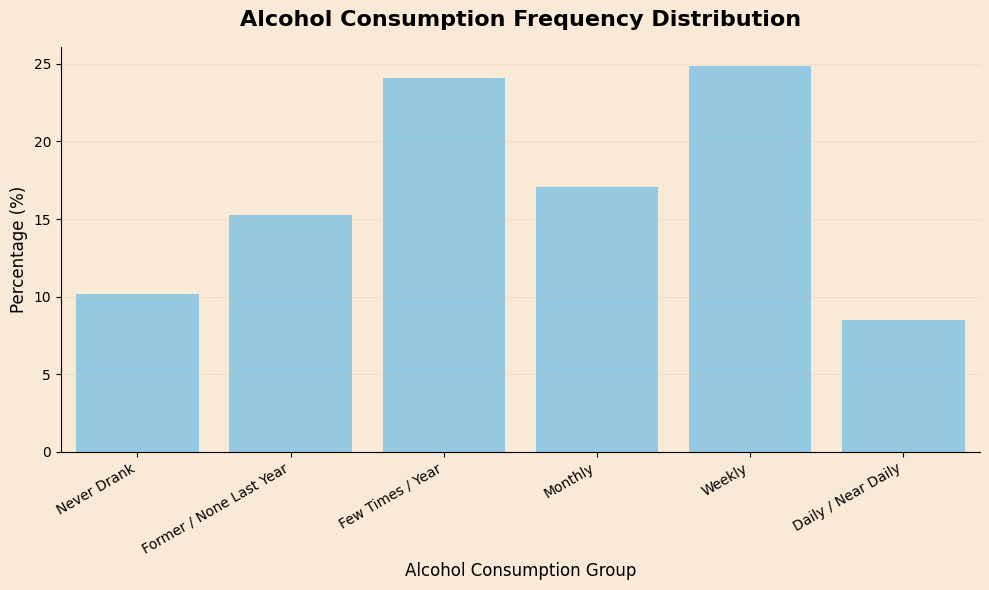

In [240]:
alcohol_dist = (
    alcohol_df["alcohol_frequency_group"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex([
        "Never Drank",
        "Former / None Last Year",
        "Few Times / Year",
        "Monthly",
        "Weekly",
        "Daily / Near Daily"
    ])
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=alcohol_dist.index,
    y=alcohol_dist.values,
    color="#88CCEE"
)

style_chart(
    title="Alcohol Consumption Frequency Distribution",
    xlabel="Alcohol Consumption Group",
    ylabel="Percentage (%)",
    rotation=30
)

plt.show()

In [241]:
# Explore distribution of alcohol consumption frequency groups
alcohol_df["alcohol_frequency_group"].value_counts()

alcohol_frequency_group
Weekly                     1361
Few Times / Year           1320
Monthly                     936
Former / None Last Year     836
Never Drank                 558
Daily / Near Daily          464
Name: count, dtype: int64

In [242]:
# Explore relationship between alcohol consumption frequency and liver enzyme levels (median GGT, ALT, AST by alcohol frequency group)

alcohol_df.groupby(
    "alcohol_frequency_group",
    observed=True
)[
    ["ggt_iu/l", "alt_iu/l", "ast_iu/l"]
].median()

,ggt_iu/l,alt_iu/l,ast_iu/l
alcohol_frequency_group,,,
Daily / Near Daily,28.0,20.0,23.0
Few Times / Year,19.0,17.0,19.0
Former / None Last Year,19.0,18.0,20.0
Monthly,19.0,18.0,19.0
Never Drank,19.0,16.0,19.0
Weekly,20.0,18.0,21.0


In [243]:
# Explore relationship between alcohol consumption frequency and liver enzyme levels (mean GGT, ALT, AST by alcohol frequency group)
alcohol_df.groupby(
    "alcohol_frequency_group",
    observed=True
)[
    ["ggt_iu/l", "alt_iu/l", "ast_iu/l"]
].mean()

,ggt_iu/l,alt_iu/l,ast_iu/l
alcohol_frequency_group,,,
Daily / Near Daily,56.390588,27.197647,28.124706
Few Times / Year,25.838435,20.758503,21.097956
Former / None Last Year,28.416107,21.342282,22.538978
Monthly,26.036817,21.928571,22.198565
Never Drank,27.297131,20.241803,21.702259
Weekly,28.544365,21.844676,22.735577


### GGT

In [244]:
alcohol_df.groupby(
    "alcohol_frequency_group",
    observed=True
)["ggt_iu/l"].describe()

,count,mean,std,min,25%,50%,75%,max
alcohol_frequency_group,,,,,,,,
Daily / Near Daily,425.0,56.390588,122.024077,7.0,17.0,28.0,47.0,1541.0
Few Times / Year,1176.0,25.838435,28.978045,4.0,13.0,19.0,28.0,407.0
Former / None Last Year,745.0,28.416107,33.695286,4.0,13.0,19.0,31.0,402.0
Monthly,842.0,26.036817,32.030081,5.0,13.0,19.0,29.0,434.0
Never Drank,488.0,27.297131,32.922718,4.0,13.0,19.0,29.0,480.0
Weekly,1251.0,28.544365,31.585291,2.0,14.0,20.0,30.0,333.0


In [245]:
alcohol_df["log_ggt"] = np.log1p(alcohol_df["ggt_iu/l"])

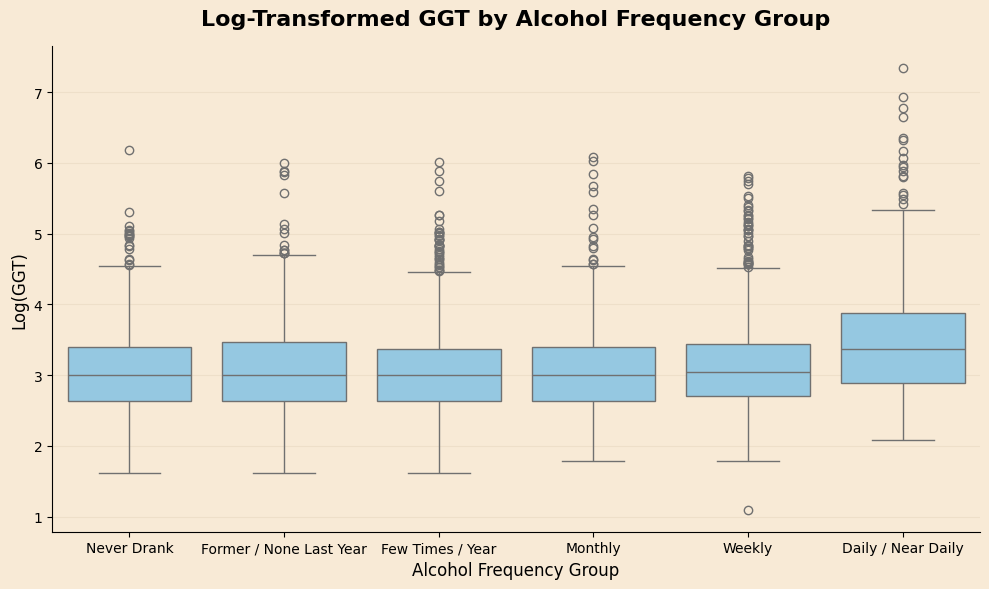

In [246]:
order = [
    "Never Drank",
    "Former / None Last Year",
    "Few Times / Year",
    "Monthly",
    "Weekly",
    "Daily / Near Daily"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=alcohol_df,
    x="alcohol_frequency_group",
    y="log_ggt",
    order=order,
    color="#88CCEE"
)

style_chart(
    title="Log-Transformed GGT by Alcohol Frequency Group",
    xlabel="Alcohol Frequency Group",
    ylabel="Log(GGT)"
)

plt.tight_layout()
plt.show()

In [247]:
alcohol_score_map = {
    "Never Drank": 0,
    "Former / None Last Year": 1,
    "Few Times / Year": 2,
    "Monthly": 3,
    "Weekly": 4,
    "Daily / Near Daily": 5
}

alcohol_df["alcohol_score"] = (
    alcohol_df["alcohol_frequency_group"]
    .map(alcohol_score_map)
)

temp = alcohol_df[
    ["alcohol_score", "log_ggt"]
].dropna()

corr, p = spearmanr(
    temp["alcohol_score"],
    temp["log_ggt"]
)

print(f"Correlation: {corr}")
print(f"P-value: {p}")

Correlation: 0.09260211417011316
P-value: 7.399416193313001e-11


In [248]:
df.columns

Index(['id', 'gender', 'age', 'ethnicity', 'weight_kg', 'height_cm', 'bmi',
       'waist_circumference_cm', 'hip_circumference_cm', 'waist_hip_ratio',
       'wbc_abs.', 'lymphocytes_abs.', 'monocytes_abs.', 'nlr',
       'neutrophils_abs.', 'rbc', 'haemoglobin_mmol/l', 'hct_%', 'mcv_fl',
       'mchcg/dl', 'mchpg', 'rdw%', 'plt1000/μl', 'mpvfl', 'ferritin_ng/ml',
       'folate_nmol/l', 'alc_consum?', 'alc_<12m?', 'alcohol_frequency_12m',
       'smoked_100_cigs?', 'smoker_now?', 'high_bp?', 'bp_medication?',
       'mean_systolic_bp', 'mean_diastolic_bp', 'mean_pulse',
       'high_cholesterol?', 'cholesterol_medication?', 'diabetes?',
       'pre_diabetes?', 'insulin?', 'diabetes_medication?', 'alt_iu/l',
       'albumin_g/l', 'ast_iu/l', 'glucose_mmol/l', 'ggt_iu/l', 'iron_μmol/l',
       'total_bilirubin_μmol/l', 'cholesterol_mmol/l', 'total_protein_g/l',
       'uric_acid_μmol/l', 'crp_mg/l', 'hba1c_%', 'vitamin_d_nmol/l',
       'total_cholesterol_mmol/l', 'ldl_mmol/l', 'hdl_mm

In [249]:
df = df.rename(columns={
    "alcohol_frequency_12m": "avg_drink_day_12m"
})

In [250]:
avg_drink_day_12m_clean = (
    df["avg_drink_day_12m"]
    .replace({
        777: pd.NA,
        999: pd.NA
    })
)

avg_drink_day_12m_clean.value_counts().sort_index()

avg_drink_day_12m
1.0     1345
2.0     1312
3.0      599
4.0      251
5.0      216
6.0      141
7.0       17
8.0       42
9.0       19
10.0      31
11.0       4
12.0      55
13.0       1
14.0       2
15.0      20
Name: count, dtype: int64

In [251]:
alcohol_qty_df = df.copy()

alcohol_qty_df["avg_drink_day_12m"] = pd.to_numeric(
    alcohol_qty_df["avg_drink_day_12m"],
    errors="coerce"
)

alcohol_qty_df["avg_drink_day_12m"] = alcohol_qty_df["avg_drink_day_12m"].replace({
    777: np.nan,
    999: np.nan
})

In [252]:
alcohol_qty_df["alcohol_quantity_group"] = pd.cut(
    alcohol_qty_df["avg_drink_day_12m"],
    bins=[0, 1, 2, 4, 15],
    labels=[
        "1 Drink",
        "2 Drinks",
        "3-4 Drinks",
        "5+ Drinks"
    ],
    include_lowest=True
)

In [253]:
alcohol_qty_df["alcohol_quantity_group"].value_counts(dropna=False)

alcohol_quantity_group
NaN           4098
1 Drink       1345
2 Drinks      1312
3-4 Drinks     850
5+ Drinks      548
Name: count, dtype: int64

In [254]:
alcohol_qty_df["log_ggt"] = np.log1p(alcohol_qty_df["ggt_iu/l"])

order = ["1 Drink", "2 Drinks", "3-4 Drinks", "5+ Drinks"]

alcohol_qty_df.groupby(
    "alcohol_quantity_group",
    observed=True
)["ggt_iu/l"].median().reindex(order)

alcohol_quantity_group
1 Drink       18.0
2 Drinks      20.0
3-4 Drinks    21.0
5+ Drinks     25.0
Name: ggt_iu/l, dtype: float64

In [255]:
ggt_median = (
    alcohol_qty_df.groupby(
        "alcohol_quantity_group",
        observed=True
    )["ggt_iu/l"]
    .median()
    .reindex([
        "1 Drink",
        "2 Drinks",
        "3-4 Drinks",
        "5+ Drinks"
    ])
)

(
    (ggt_median - ggt_median["1 Drink"])
    / ggt_median["1 Drink"]
    * 100
).round(1)

alcohol_quantity_group
1 Drink        0.0
2 Drinks      11.1
3-4 Drinks    16.7
5+ Drinks     38.9
Name: ggt_iu/l, dtype: float64

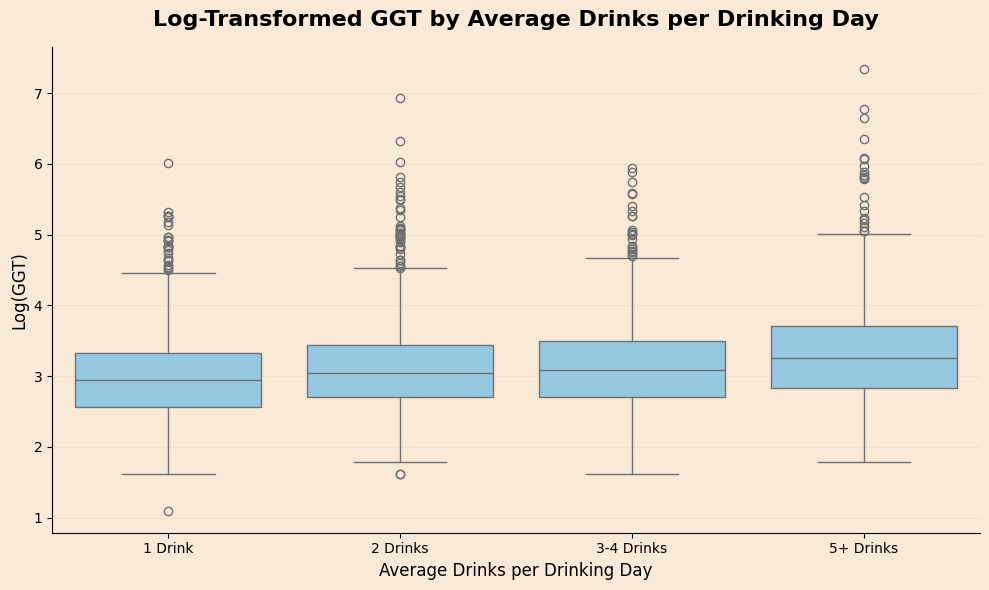

In [256]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=alcohol_qty_df,
    x="alcohol_quantity_group",
    y="log_ggt",
    order=order,
    color="#88CCEE"
)

style_chart(
    title="Log-Transformed GGT by Average Drinks per Drinking Day",
    xlabel="Average Drinks per Drinking Day",
    ylabel="Log(GGT)"
)

plt.show()

In [257]:

temp = alcohol_qty_df[
    ["avg_drink_day_12m", "log_ggt"]
].dropna()

corr, p = spearmanr(
    temp["avg_drink_day_12m"],
    temp["log_ggt"]
)

print(f"Spearman r = {corr:.3f}")
print(f"P-value = {p:.4e}")

Spearman r = 0.146
P-value = 5.8033e-19


In [258]:
markers = [
    "ggt_iu/l",
    "alt_iu/l",
    "ast_iu/l",
    "total_bilirubin_μmol/l"
]

pct_results = []

for col in markers:

    medians = alcohol_qty_df.groupby(
        "alcohol_quantity_group",
        observed=True
    )[col].median()

    pct_change = (
        (medians["5+ Drinks"] - medians["1 Drink"])
        / medians["1 Drink"] * 100
    )

    pct_results.append({
        "Marker": col,
        "% Increase (5+ Drinks vs 1 Drink)": round(pct_change, 1)
    })

pct_table = pd.DataFrame(pct_results)

pct_table

,Marker,% Increase (5+ Drinks vs 1 Drink)
0,ggt_iu/l,38.9
1,alt_iu/l,17.6
2,ast_iu/l,5.0
3,total_bilirubin_μmol/l,0.0


In [259]:


corr_results = []

for col in markers:

    temp = alcohol_qty_df[
        ["avg_drink_day_12m", col]
    ].dropna()

    corr, p = spearmanr(
        temp["avg_drink_day_12m"],
        temp[col]
    )

    corr_results.append({
        "Marker": col,
        "Spearman r": round(corr, 3),
        "p-value": p
    })

alcohol_corr_table = pd.DataFrame(corr_results)

alcohol_corr_table

,Marker,Spearman r,p-value
0,ggt_iu/l,0.146,5.803292e-19
1,alt_iu/l,0.110,2.013767e-11
2,ast_iu/l,0.051,1.860682e-03
3,total_bilirubin_μmol/l,-0.015,3.527473e-01


In [260]:
alcohol_summary = pct_table.merge(
    alcohol_corr_table,
    on="Marker"
)

alcohol_summary.sort_values(
    "Spearman r",
    ascending=False
)

,Marker,% Increase (5+ Drinks vs 1 Drink),Spearman r,p-value
0,ggt_iu/l,38.9,0.146,5.803292e-19
1,alt_iu/l,17.6,0.110,2.013767e-11
2,ast_iu/l,5.0,0.051,1.860682e-03
3,total_bilirubin_μmol/l,0.0,-0.015,3.527473e-01


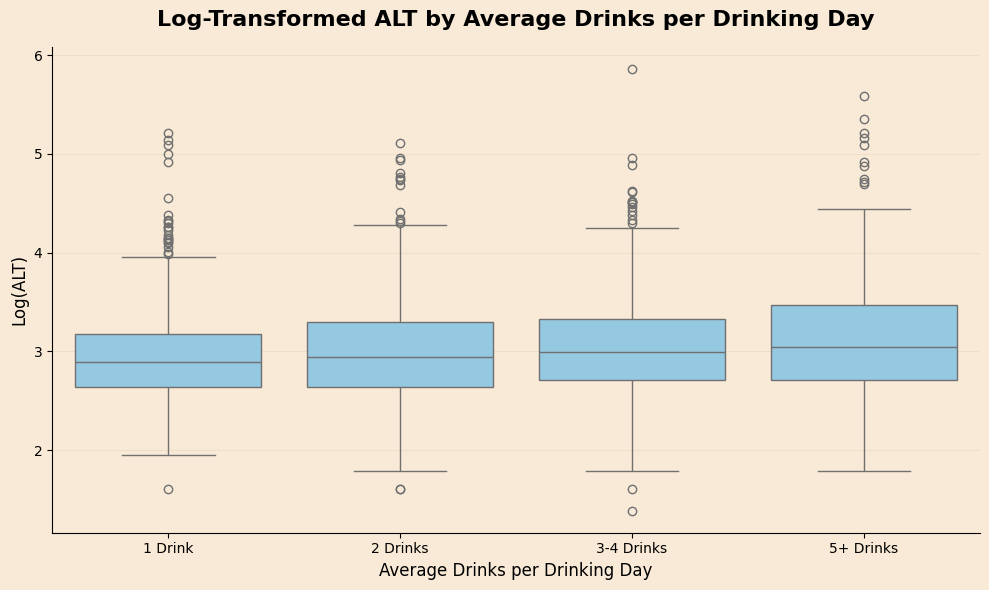

In [261]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=alcohol_qty_df,
    x="alcohol_quantity_group",
    y=np.log1p(alcohol_qty_df["alt_iu/l"]),
    order=["1 Drink", "2 Drinks", "3-4 Drinks", "5+ Drinks"],
    color="#88CCEE"
)

style_chart(
    title="Log-Transformed ALT by Average Drinks per Drinking Day",
    xlabel="Average Drinks per Drinking Day",
    ylabel="Log(ALT)"
)

plt.show()

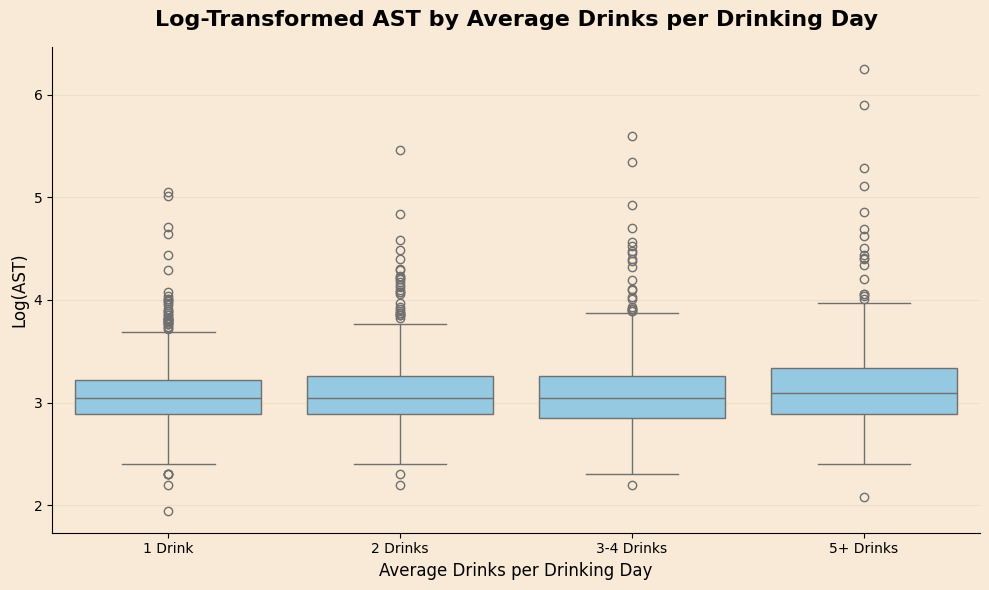

In [262]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=alcohol_qty_df,
    x="alcohol_quantity_group",
    y=np.log1p(alcohol_qty_df["ast_iu/l"]),
    order=["1 Drink", "2 Drinks", "3-4 Drinks", "5+ Drinks"],
    color="#88CCEE"
)

style_chart(
    title="Log-Transformed AST by Average Drinks per Drinking Day",
    xlabel="Average Drinks per Drinking Day",
    ylabel="Log(AST)"
)

plt.show()

In [29]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=alcohol_qty_df,
    x="alcohol_quantity_group",
    y=np.log1p(alcohol_qty_df["total_bilirubin_μmol/l"]),
    order=["1 Drink", "2 Drinks", "3-4 Drinks", "5+ Drinks"],
    color="#88CCEE"
)

style_chart(
    title="Log-Transformed Bilirubin by Average Drinks per Drinking Day",
    xlabel="Average Drinks per Drinking Day",
    ylabel="Log(Bilirubin)"
)

plt.show()

NameError: name 'alcohol_qty_df' is not defined

<Figure size 1000x600 with 0 Axes>

In [20]:
df.columns

Index(['id', 'gender', 'age', 'ethnicity', 'weight_kg', 'height_cm', 'bmi',
       'waist_circumference_cm', 'hip_circumference_cm', 'waist_hip_ratio',
       'wbc_abs.', 'lymphocytes_abs.', 'monocytes_abs.', 'nlr',
       'neutrophils_abs.', 'rbc', 'haemoglobin_mmol/l', 'hct_%', 'mcv_fl',
       'mchcg/dl', 'mchpg', 'rdw%', 'plt1000/μl', 'mpvfl', 'ferritin_ng/ml',
       'folate_nmol/l', 'alc_consum?', 'alc_<12m?', 'avg_drink_day_12m',
       'smoked_100_cigs?', 'smoker_now?', 'high_bp?', 'bp_medication?',
       'mean_systolic_bp', 'mean_diastolic_bp', 'mean_pulse',
       'high_cholesterol?', 'cholesterol_medication?', 'diabetes?',
       'pre_diabetes?', 'insulin?', 'diabetes_medication?', 'alt_iu/l',
       'albumin_g/l', 'ast_iu/l', 'glucose_mmol/l', 'ggt_iu/l', 'iron_μmol/l',
       'total_bilirubin_μmol/l', 'cholesterol_mmol/l', 'total_protein_g/l',
       'uric_acid_μmol/l', 'crp_mg/l', 'hba1c_%', 'vitamin_d_nmol/l',
       'total_cholesterol_mmol/l', 'ldl_mmol/l', 'hdl_mmol/l

In [25]:
freq_corr = df["alcohol_frequency_score"].corr(
    df["ggt_iu/l"],
    method="spearman"
)

quantity_corr = df["avg_drink_day_12m"].corr(
    df["ggt_iu/l"],
    method="spearman"
)

print("Frequency:", freq_corr)
print("Quantity:", quantity_corr)

Frequency: 0.12415793121284245
Quantity: 0.14522927783215558


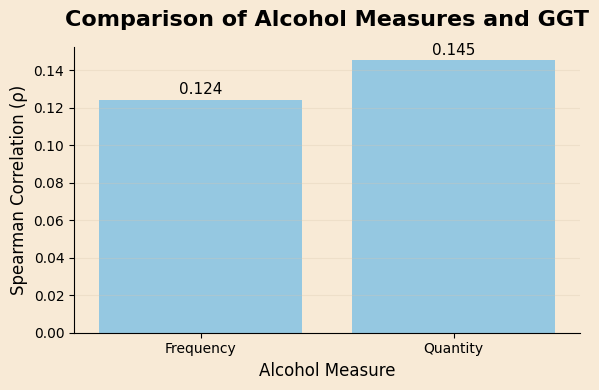

In [26]:
freq_corr = df["alcohol_frequency_score"].corr(
    df["ggt_iu/l"],
    method="spearman"
)

quantity_corr = df["avg_drink_day_12m"].corr(
    df["ggt_iu/l"],
    method="spearman"
)

compare_df = pd.DataFrame({
    "Measure": ["Frequency", "Quantity"],
    "Spearman r": [freq_corr, quantity_corr]
})

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=compare_df,
    x="Measure",
    y="Spearman r",
    color="#88CCEE"
)

for i, value in enumerate(compare_df["Spearman r"]):
    ax.text(
        i,
        value + 0.003,
        f"{value:.3f}",
        ha="center",
        fontsize=11
    )

style_chart(
    title="Comparison of Alcohol Measures and GGT",
    xlabel="Alcohol Measure",
    ylabel="Spearman Correlation (ρ)"
)

plt.show()

In [266]:
alcohol_qty_df.groupby(
    "alcohol_quantity_group",
    observed=True
)["mcv_fl"].median()

alcohol_quantity_group
1 Drink       89.30
2 Drinks      89.10
3-4 Drinks    89.40
5+ Drinks     88.85
Name: mcv_fl, dtype: float64

In [267]:
mcv_median = (
    alcohol_qty_df.groupby(
        "alcohol_quantity_group",
        observed=True
    )["mcv_fl"]
    .median()
)

(
    (mcv_median - mcv_median["1 Drink"])
    / mcv_median["1 Drink"]
    * 100
).round(1)

alcohol_quantity_group
1 Drink       0.0
2 Drinks     -0.2
3-4 Drinks    0.1
5+ Drinks    -0.5
Name: mcv_fl, dtype: float64

In [268]:
import statsmodels.api as sm

model_df = df[
    [
        "log_crp",
        "bmi",
        "age",
        "gender",
        "smoking_score"
    ]
].dropna()

X = model_df[
    [
        "bmi",
        "age",
        "gender",
        "smoking_score"
    ]
]

X = sm.add_constant(X)

y = model_df["log_crp"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_crp   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     492.3
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        08:36:07   Log-Likelihood:                -5705.0
No. Observations:                5732   AIC:                         1.142e+04
Df Residuals:                    5727   BIC:                         1.145e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.6219      0.051    -12.313

In [269]:
model_df = df[
    [
        "log_crp",
        "bmi",
        "waist_hip_ratio",
        "age",
        "gender",
        "smoking_score",
        "avg_drink_day_12m"
    ]
].dropna()

X = model_df[
    [
        "bmi",
        "waist_hip_ratio",
        "age",
        "gender",
        "smoking_score",
        "avg_drink_day_12m"
    ]
]

X = sm.add_constant(X)

y = model_df["log_crp"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_crp   R-squared:                       0.273
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     228.4
Date:                Wed, 03 Jun 2026   Prob (F-statistic):          2.57e-248
Time:                        08:37:51   Log-Likelihood:                -3545.5
No. Observations:                3664   AIC:                             7105.
Df Residuals:                    3657   BIC:                             7148.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.5781      0.15

In [270]:
results_table = pd.DataFrame({
    "Variable": model.params.index,
    "Coefficient": model.params.values,
    "p-value": model.pvalues.values
})

results_table = results_table.round({
    "Coefficient": 3,
    "p-value": 4
})

results_table

,Variable,Coefficient,p-value
0,const,-1.578,0.0000
1,bmi,0.048,0.0000
2,waist_hip_ratio,1.025,0.0000
3,age,-0.001,0.0998
4,gender,0.260,0.0000
5,smoking_score,0.058,0.0000
6,avg_drink_day_12m,-0.000,0.5858


In [ ]:


corr, p = spearmanr(
    df["bmi"],
    df["waist_hip_ratio"],
    nan_policy="omit"
)

print(corr)

0.3956109070751652


## Triglycerides and HbA1c

In [272]:


temp = df[
    ["triglycerides_mmol/l", "crp_mg/l"]
].dropna()

corr, p = spearmanr(
    temp["triglycerides_mmol/l"],
    temp["crp_mg/l"]
)

print("Spearman r =", corr)
print("p-value =", p)

Spearman r = 0.2528866751169416
p-value = 1.0212108191620531e-47


In [278]:
print(df["triglycerides_mmol/l"].describe())
print(df["hba1c_%"].describe())

count    3189.000000
mean        1.348619
std         0.980269
min         0.215000
25%         0.813000
50%         1.106000
75%         1.581000
max        19.701000
Name: triglycerides_mmol/l, dtype: float64
count    6002.000000
mean        5.764528
std         1.098250
min         3.200000
25%         5.200000
50%         5.500000
75%         5.900000
max        17.100000
Name: hba1c_%, dtype: float64


In [279]:
df["hba1c_group"] = pd.cut(
    df["hba1c_%" ],
    bins=[0, 5.7, 6.5, 20],
    labels=[
        "Normal",
        "Prediabetes",
        "Diabetes"
    ]
)

df["hba1c_group"].value_counts()

hba1c_group
Normal         4082
Prediabetes    1254
Diabetes        666
Name: count, dtype: int64

In [280]:
df["triglyceride_group"] = pd.cut(
    df["triglycerides_mmol/l"],
    bins=[0, 1.7, 2.3, 5.6, 25],
    labels=[
        "Normal",
        "Borderline High",
        "High",
        "Very High"
    ]
)

df["triglyceride_group"].value_counts()

triglyceride_group
Normal             2512
Borderline High     362
High                294
Very High            21
Name: count, dtype: int64

In [281]:
df["triglyceride_group"] = pd.cut(
    df["triglycerides_mmol/l"],
    bins=[0, 1.7, 2.3, 25],
    labels=[
        "Normal",
        "Borderline High",
        "High"
    ]
)

In [282]:
df["triglyceride_group"].value_counts()

triglyceride_group
Normal             2512
Borderline High     362
High                315
Name: count, dtype: int64

In [ ]:
#calculate median CRP by triglyceride group

df.groupby(
    "triglyceride_group",
    observed=True
)["crp_mg/l"].median()

triglyceride_group
Normal             1.62
Borderline High    2.48
High               2.67
Name: crp_mg/l, dtype: float64

In [284]:
df.groupby(
    "hba1c_group",
    observed=True
)["crp_mg/l"].median()

hba1c_group
Normal         1.490
Prediabetes    2.635
Diabetes       2.895
Name: crp_mg/l, dtype: float64

In [304]:
# Triglycerides
trig_median = (
    df.groupby(
        "triglyceride_group",
        observed=True
    )["crp_mg/l"]
    .median()
)

trig_pct = (
    (trig_median - trig_median["Normal"])
    / trig_median["Normal"]
    * 100
).round(1)

trig_pct

triglyceride_group
Normal              0.0
Borderline High    53.1
High               64.8
Name: crp_mg/l, dtype: float64

In [302]:
# HbA1c
hba1c_median = (
    df.groupby(
        "hba1c_group",
        observed=True
    )["crp_mg/l"]
    .median()
)

hba1c_pct = (
    (hba1c_median - hba1c_median["Normal"])
    / hba1c_median["Normal"]
    * 100
).round(1)

hba1c_pct

hba1c_group
Normal          0.0
Prediabetes    76.8
Diabetes       94.3
Name: crp_mg/l, dtype: float64

In [287]:

temp = df[
    ["triglycerides_mmol/l", "crp_mg/l"]
].dropna()

corr, p = spearmanr(
    temp["triglycerides_mmol/l"],
    temp["crp_mg/l"]
)

print(f"Spearman r = {corr:.3f}")
print(f"P-value = {p:.4e}")

Spearman r = 0.253
P-value = 1.0212e-47


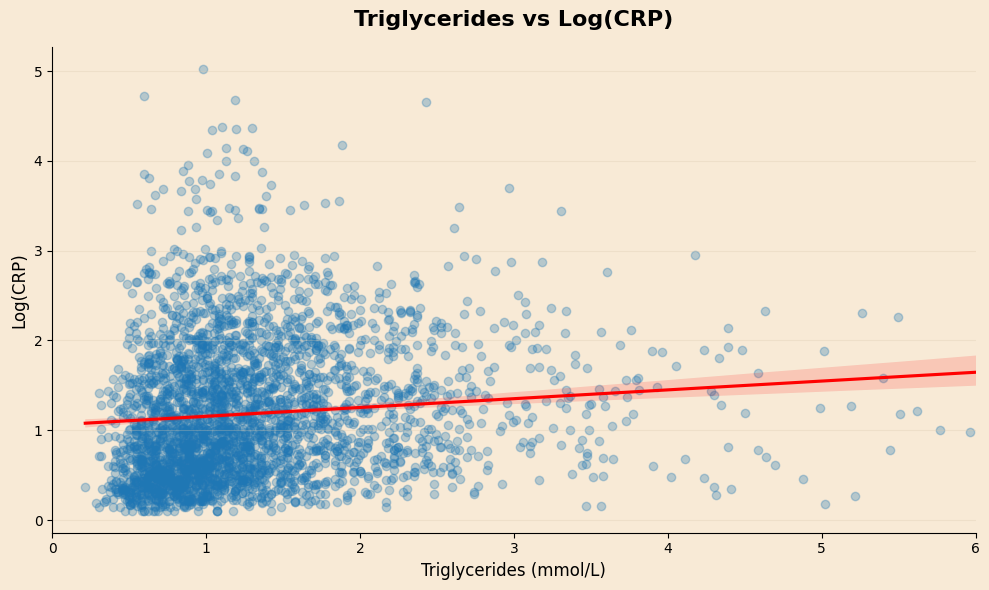

In [293]:
plt.figure(figsize=(10,6)),
plt.xlim(0, 6)
sns.regplot(
    data=df,
    x="triglycerides_mmol/l",
    y="log_crp",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

style_chart(
    title="Triglycerides vs Log(CRP)",
    xlabel="Triglycerides (mmol/L)",
    ylabel="Log(CRP)"
)

plt.show()

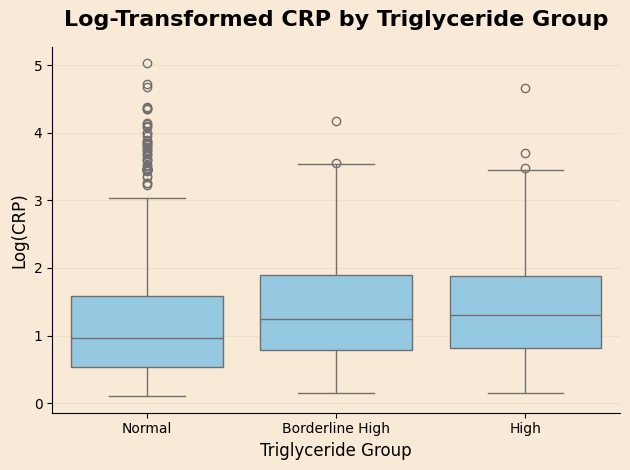

In [292]:
sns.boxplot(
    data=df,
    x="triglyceride_group",
    y="log_crp",
    color="#88CCEE"
)

style_chart(
    title="Log-Transformed CRP by Triglyceride Group",
    xlabel="Triglyceride Group",
    ylabel="Log(CRP)"
)

In [294]:
temp = df[
    ["hba1c_%", "crp_mg/l"]
].dropna()

corr, p = spearmanr(
    temp["hba1c_%"],
    temp["crp_mg/l"]
)

print(f"Spearman r = {corr:.3f}")
print(f"P-value = {p:.4e}")

Spearman r = 0.243
P-value = 9.7507e-79


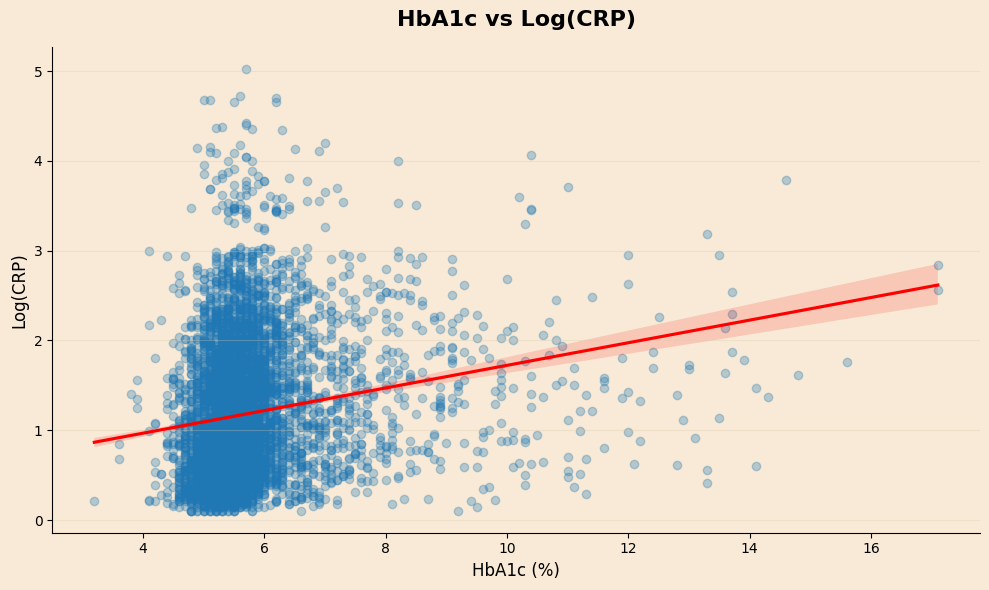

In [296]:
plt.figure(figsize=(10,6)),

sns.regplot(
    data=df,
    x="hba1c_%",
    y="log_crp",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

style_chart(
    title="HbA1c vs Log(CRP)",
    xlabel="HbA1c (%)",
    ylabel="Log(CRP)"
)

plt.show()

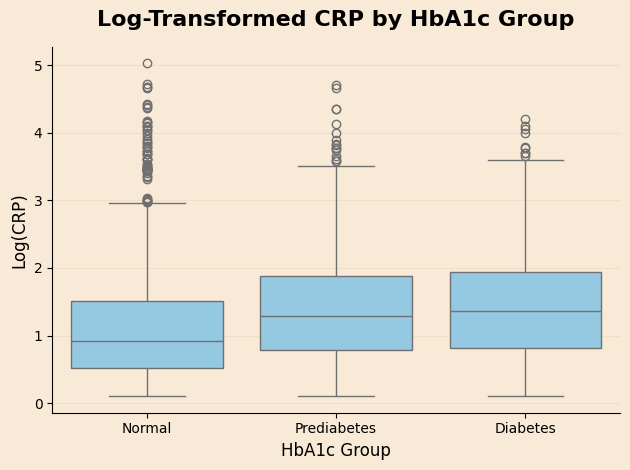

In [297]:
sns.boxplot(
    data=df,
    x="hba1c_group",
    y="log_crp",
    color="#88CCEE"
)

style_chart(
    title="Log-Transformed CRP by HbA1c Group",
    xlabel="HbA1c Group",
    ylabel="Log(CRP)"
)

In [303]:
hba1c_summary = pd.DataFrame({
    "Median CRP (mg/L)": hba1c_median,
    "% Increase vs Normal": hba1c_pct
})

hba1c_summary

,Median CRP (mg/L),% Increase vs Normal
hba1c_group,,
Normal,1.490,0.0
Prediabetes,2.635,76.8
Diabetes,2.895,94.3


In [305]:
trig_summary = pd.DataFrame({
    "Median CRP (mg/L)": trig_median,
    "% Increase vs Normal": trig_pct
})

trig_summary

,Median CRP (mg/L),% Increase vs Normal
triglyceride_group,,
Normal,1.62,0.0
Borderline High,2.48,53.1
High,2.67,64.8


In [308]:
results = []

# Triglycerides
trig_median = (
    df.groupby(
        "triglyceride_group",
        observed=True
    )["crp_mg/l"]
    .median()
)

trig_pct = (
    (trig_median["High"] - trig_median["Normal"])
    / trig_median["Normal"]
    * 100
)

temp = df[
    ["triglycerides_mmol/l", "crp_mg/l"]
].dropna()

trig_r, _ = spearmanr(
    temp["triglycerides_mmol/l"],
    temp["crp_mg/l"]
)

results.append({
    "Variable": "Triglycerides",
    "Reference Group": "Normal",
    "Highest Group": "High",
    "Median CRP Reference": round(trig_median["Normal"], 2),
    "Median CRP Highest": round(trig_median["High"], 2),
    "% Increase": round(trig_pct, 1),
    "Spearman r": round(trig_r, 3)
})


# HbA1c
hba1c_median = (
    df.groupby(
        "hba1c_group",
        observed=True
    )["crp_mg/l"]
    .median()
)

hba1c_pct = (
    (hba1c_median["Diabetes"] - hba1c_median["Normal"])
    / hba1c_median["Normal"]
    * 100
)

temp = df[
    ["hba1c_%", "crp_mg/l"]
].dropna()

hba1c_r, _ = spearmanr(
    temp["hba1c_%"],
    temp["crp_mg/l"]
)

results.append({
    "Variable": "HbA1c",
    "Reference Group": "Normal",
    "Highest Group": "Diabetes",
    "Median CRP Reference": round(hba1c_median["Normal"], 2),
    "Median CRP Highest": round(hba1c_median["Diabetes"], 2),
    "% Increase": round(hba1c_pct, 1),
    "Spearman r": round(hba1c_r, 3)
})

metabolic_summary = pd.DataFrame(results)

metabolic_summary

,Variable,Reference Group,Highest Group,Median CRP Reference,Median CRP Highest,% Increase,Spearman r
0,Triglycerides,Normal,High,1.62,2.67,64.8,0.253
1,HbA1c,Normal,Diabetes,1.49,2.90,94.3,0.243
